# ThinkMoney: Modelo de Clusterização de Personas Financeiras

## Estrutura do Notebook
- **Bloco 1: Preparação dos Dados** (compartilhado entre K-Means++ e DBSCAN)
- **Bloco 2: DBSCAN**
- **Bloco 3: K-Means++**

## Bloco 1: Preparação dos Dados
### 1.1 Importação de Bibliotecas

In [1]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np
import shap
import openpyxl

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Bibliotecas carregadas com sucesso!")

C:\Users\pedro\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas carregadas com sucesso!


### 1.2 Carregamento e Inspeção Inicial do Dataset

In [2]:
df = pd.read_parquet('data.parquet')

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"\nColunas disponíveis:\n{df.columns.tolist()}")

Linhas: 20000
Colunas: 27

Colunas disponíveis:
['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']


In [3]:
display(df.head())

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [4]:
# City_Tier: ordinal (Tier_1 é maior que Tier_3 em infraestrutura)
city_map = {'Tier_1': 3, 'Tier_2': 2, 'Tier_3': 1}
df['City_Tier_enc'] = df['City_Tier'].map(city_map)

print(df[['City_Tier_enc']].head())

   City_Tier_enc
0              3
1              2
2              1
3              1
4              2


### 1.3 Análise Exploratória (EDA)

In [5]:
print("=== Tipos de cada coluna ===")
print(df.dtypes)

print("\n=== Valores nulos por coluna ===")
print(df.isnull().sum())

=== Tipos de cada coluna ===
Income                             float64
Age                                  int64
Dependents                           int64
Occupation                             str
City_Tier                              str
Rent                               float64
Loan_Repayment                     float64
Insurance                          float64
Groceries                          float64
Transport                          float64
Eating_Out                         float64
Entertainment                      float64
Utilities                          float64
Healthcare                         float64
Education                          float64
Miscellaneous                      float64
Desired_Savings_Percentage         float64
Desired_Savings                    float64
Disposable_Income                  float64
Potential_Savings_Groceries        float64
Potential_Savings_Transport        float64
Potential_Savings_Eating_Out       float64
Potential_Savings_Enterta

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Income,20000.0,41585.496104,40014.540538,1301.187333,17604.875957,30185.383480,51765.446460,1.079728e+06
Age,20000.0,41.031450,13.578725,18.000000,29.000000,41.000000,53.000000,6.400000e+01
Dependents,20000.0,1.995950,1.417616,0.000000,1.000000,2.000000,3.000000,4.000000e+00
Rent,20000.0,9115.494629,9254.228188,235.365692,3649.422246,6402.751824,11263.940492,2.159457e+05
Loan_Repayment,20000.0,2049.800292,4281.789941,0.000000,0.000000,0.000000,2627.142320,1.230807e+05
Insurance,20000.0,1455.028761,1492.938435,30.002012,580.204749,1017.124681,1787.160895,3.873493e+04
Groceries,20000.0,5205.667493,5035.953689,154.078240,2165.426419,3741.091535,6470.892718,1.198169e+05
Transport,20000.0,2704.466685,2666.345648,81.228584,1124.578012,1933.845509,3360.597508,8.186150e+04
Eating_Out,20000.0,1461.856982,1481.660811,39.437523,581.011801,1029.109726,1807.075251,3.440610e+04
Entertainment,20000.0,1448.853658,1489.019270,45.421469,581.632906,1020.198376,1790.104082,3.866737e+04


In [7]:
print("=== Ocupações ===")
print(df['Occupation'].value_counts())

print("\n=== City Tier ===")
print(df['City_Tier'].value_counts())

=== Ocupações ===
Occupation
Retired          5019
Professional     5011
Student          5003
Self_Employed    4967
Name: count, dtype: int64

=== City Tier ===
City_Tier
Tier_2    10068
Tier_1     5934
Tier_3     3998
Name: count, dtype: int64


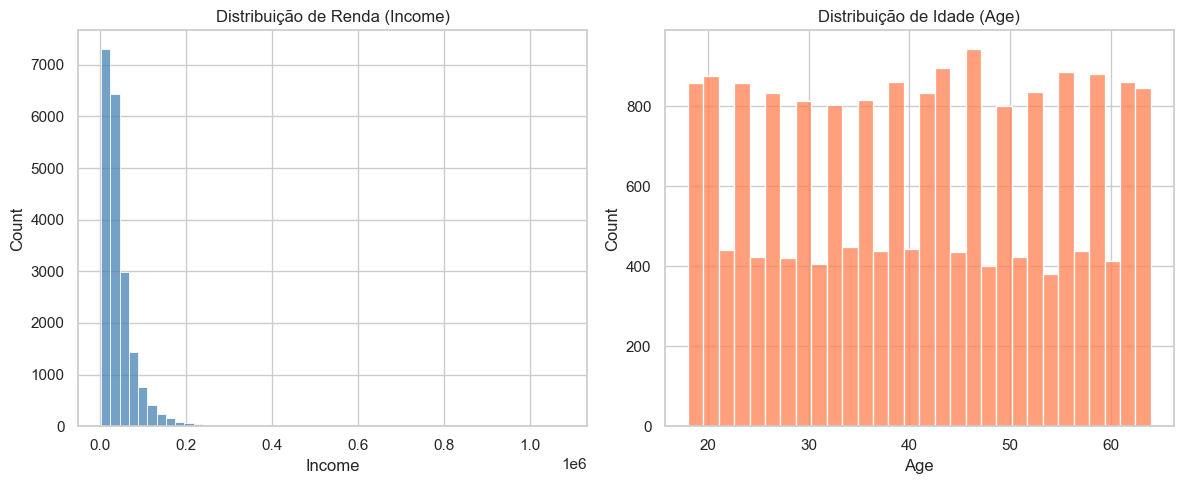

In [8]:
fig, axes = plt.subplots(1, 2)

sns.histplot(df['Income'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de Renda (Income)')

sns.histplot(df['Age'], bins=30, ax=axes[1], color='coral')
axes[1].set_title('Distribuição de Idade (Age)')

plt.tight_layout()
plt.show()

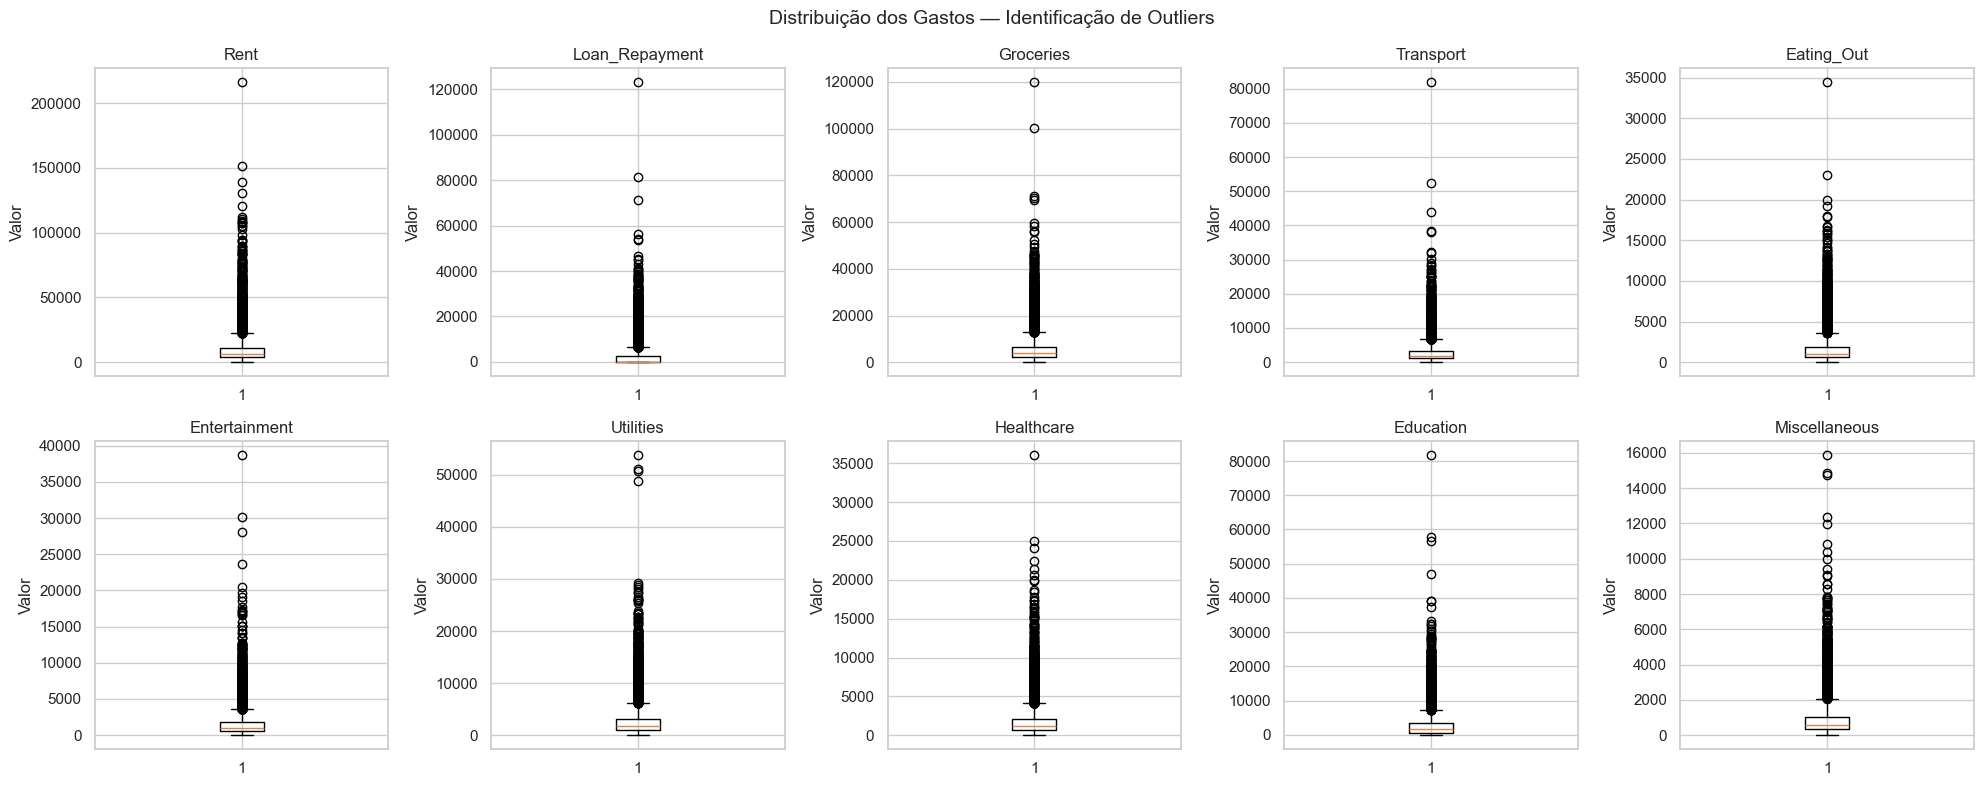

In [9]:
colunas_gastos = ['Rent', 'Loan_Repayment', 'Groceries', 'Transport',
                   'Eating_Out', 'Entertainment', 'Utilities',
                   'Healthcare', 'Education', 'Miscellaneous']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_gastos):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

plt.suptitle('Distribuição dos Gastos — Identificação de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

### 1.4 Correlação entre Variáveis Brutas

O mapa abaixo evidencia a alta correlação entre as variáveis financeiras brutas e a renda (Income), motivando a transformação proporcional aplicada na etapa seguinte.

In [10]:
colunas_modelo = [
    'Age', 'Dependents',
    'Rent', 'Loan_Repayment', 'Insurance',
    'Groceries', 'Transport', 'Eating_Out',
    'Entertainment', 'Utilities', 'Healthcare',
    'Education', 'Miscellaneous',
    'Desired_Savings_Percentage'
]

df_eda = df[colunas_modelo].copy()
print(f"Shape: {df_eda.shape}")
display(df_eda.head())

Shape: (20000, 14)


,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage
0,49,0,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948
1,34,2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376
2,35,1,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808
3,21,0,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,6128.550387,4571.118217,0.000000,2526.055712,16.455440
4,52,4,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982


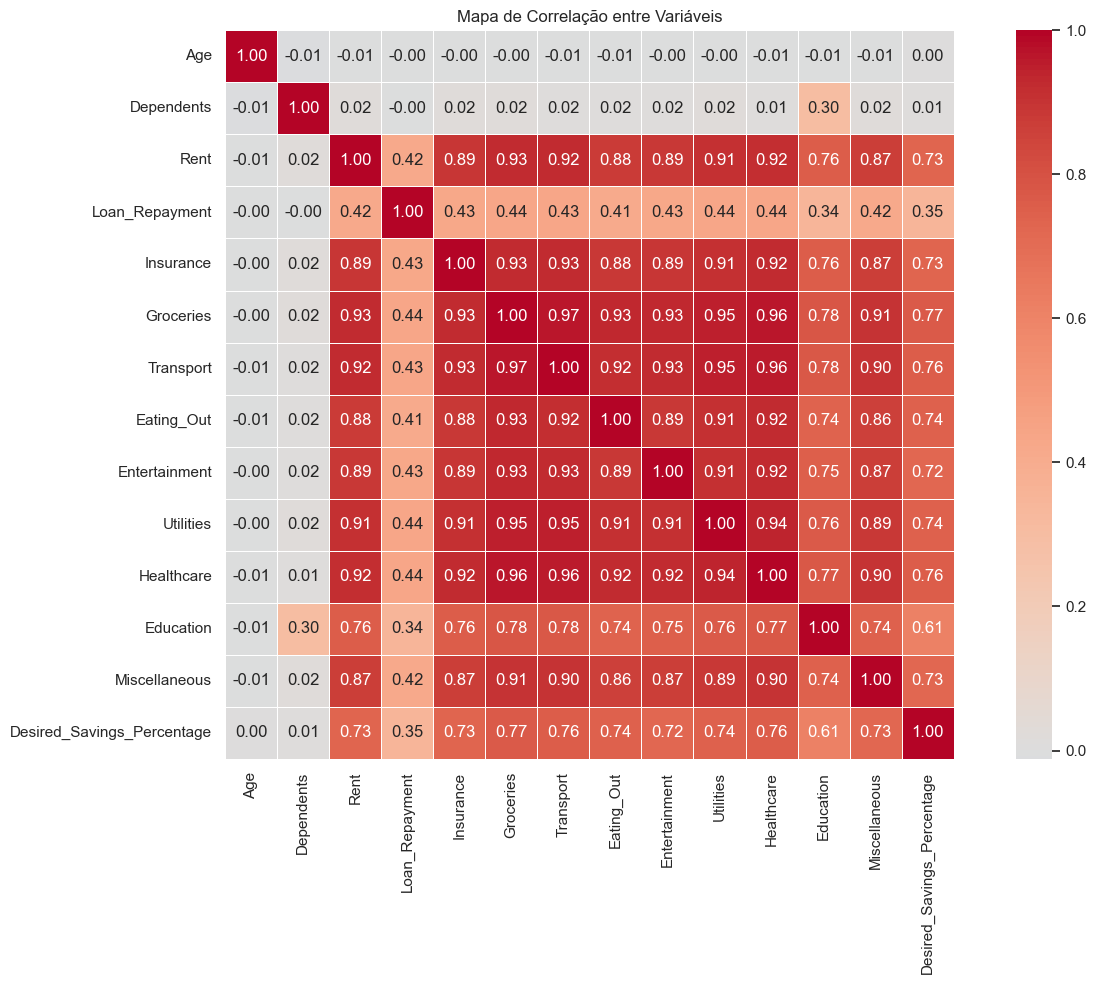

In [11]:
plt.figure(figsize=(14, 10))
correlacao = df_eda.corr()
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Mapa de Correlação entre Variáveis')
plt.tight_layout()
plt.show()

### 1.5 Feature Engineering — Variáveis Proporcionais

As variáveis financeiras foram transformadas em ratios proporcionais à renda (*ratio features*), eliminando a dominância do Income e permitindo que o modelo capture padrões comportamentais independentes do nível de renda.

O conjunto de 11 variáveis compartilha o mesmo core do modelo de classificação desenvolvido em paralelo, variando apenas no formato de representação.

In [12]:
df_modelo = pd.DataFrame()

# --- Core compartilhado com modelo de classificação ---
# Mesmas variáveis do João, formato proporcional para capturar comportamento

df_modelo['Rent_pct']            = df['Rent'] / df['Income']
df_modelo['Loan_Repayment_pct']  = df['Loan_Repayment'] / df['Income']
df_modelo['Disposable_pct']      = df['Disposable_Income'] / df['Income']
df_modelo['Desired_Savings_pct'] = df['Desired_Savings_Percentage'] / 100
df_modelo['Age']                 = df['Age']
df_modelo['Dependents']          = df['Dependents']

# --- Variável exclusiva do modelo de clusterização ---
# Gap entre meta de poupança e capacidade real — não existe no João
# porque classificação não precisa dessa diferença, clusterização sim
df_modelo['Gap_Poupanca'] = (df['Desired_Savings_Percentage'] / 100) - \
                            (df['Disposable_Income'] / df['Income'])

# --- Variável de contexto urbano ---
df_modelo['City_Tier_enc']       = df['City_Tier'].map({'Tier_1': 3, 'Tier_2': 2, 'Tier_3': 1})

# --- Variáveis agregadas (reduzem ruído mantendo informação) ---
# Gastos de consumo: Groceries + Eating_Out + Entertainment
df_modelo['Gastos_Consumo_pct']  = (df['Groceries'] + df['Eating_Out'] +
                                     df['Entertainment']) / df['Income']

# Gastos fixos complementares: Insurance + Transport + Healthcare
df_modelo['Gastos_Fixos_pct']    = (df['Insurance'] + df['Transport'] +
                                     df['Healthcare']) / df['Income']

print(f"Total de variáveis: {df_modelo.shape[1]}")
print(df_modelo.columns.tolist())

Total de variáveis: 10
['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct', 'Desired_Savings_pct', 'Age', 'Dependents', 'Gap_Poupanca', 'City_Tier_enc', 'Gastos_Consumo_pct', 'Gastos_Fixos_pct']


### 1.6 Correlação entre Variáveis Proporcionais

Após a transformação, a correlação entre as variáveis cai drasticamente, confirmando que a dominância da renda foi removida com sucesso.

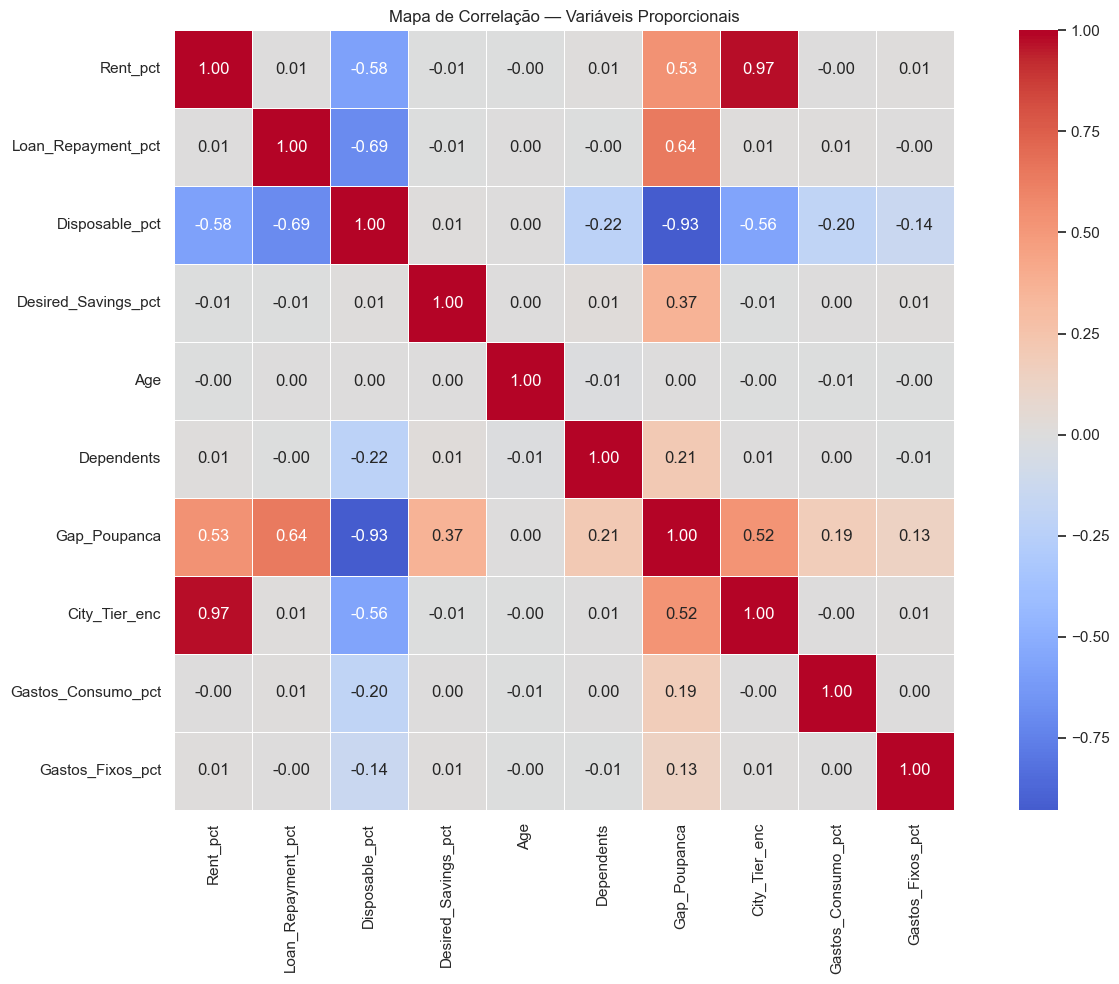

In [13]:
plt.figure(figsize=(14, 10))
colunas_corr = [c for c in df_modelo.columns if c != 'Cluster']
sns.heatmap(df_modelo[colunas_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Mapa de Correlação — Variáveis Proporcionais')
plt.tight_layout()
plt.show()

### 1.7 Normalização e Redução de Dimensionalidade

**RobustScaler**: normalização robusta a outliers, usando mediana e IQR em vez de média e desvio padrão.

**PCA**: redução de dimensionalidade preservando 85% da variância acumulada, justificada pelo número de variáveis e pela correlação residual entre elas.

In [14]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_normalizado = scaler.fit_transform(df_modelo)

print("Dados normalizados com RobustScaler!")
print(f"Shape: {df_normalizado.shape}")

Dados normalizados com RobustScaler!
Shape: (20000, 10)


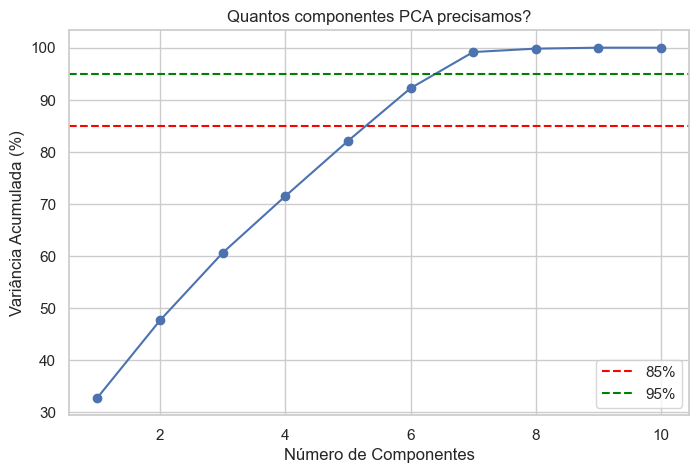

1 componentes: 32.8%
2 componentes: 47.7%
3 componentes: 60.6%
4 componentes: 71.5%
5 componentes: 82.1%
6 componentes: 92.2%
7 componentes: 99.2%
8 componentes: 99.8%
9 componentes: 100.0%
10 componentes: 100.0%


In [15]:
from sklearn.decomposition import PCA

pca_analise = PCA()
pca_analise.fit(df_normalizado)

variancia_acumulada = pca_analise.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada * 100, 'bo-')
plt.axhline(y=85, color='red', linestyle='--', label='85%')
plt.axhline(y=95, color='green', linestyle='--', label='95%')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Acumulada (%)')
plt.title('Quantos componentes PCA precisamos?')
plt.legend()
plt.grid(True)
plt.show()

for i, v in enumerate(variancia_acumulada):
    print(f"{i+1} componentes: {v*100:.1f}%")

In [16]:
# PCA com 85% de variância acumulada
pca = PCA(n_components=0.85, random_state=42)
df_pca = pca.fit_transform(df_normalizado)

print(f"Variância preservada: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"Shape: {df_pca.shape}")

Variância preservada: 92.2%
Shape: (20000, 6)


### 1.8 Visualização Exploratória: Espaço PCA 2D

Projeção dos dados nos dois primeiros componentes principais, antes da aplicação de qualquer algoritmo de clusterização.

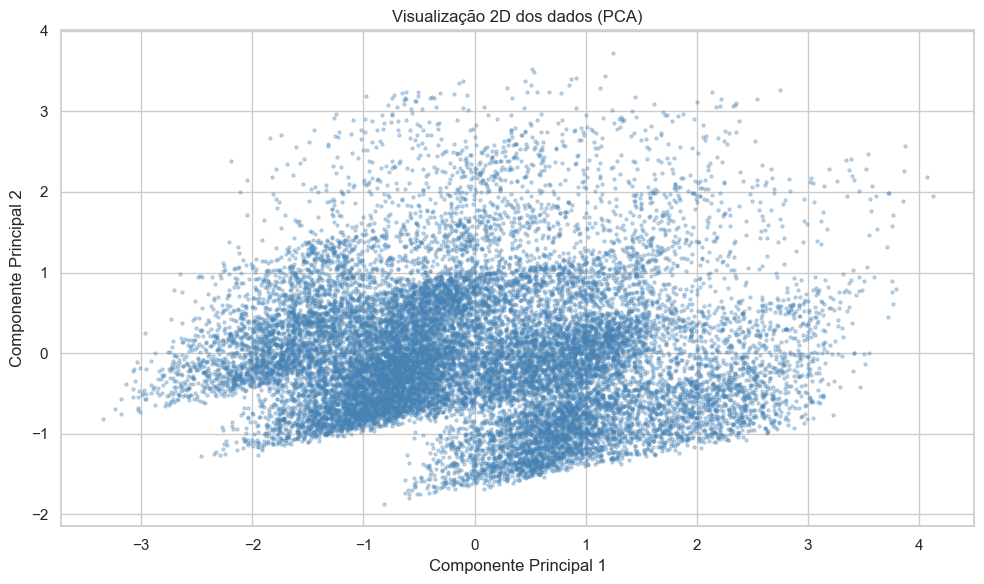

In [17]:
# Para visualizar usamos só 2 componentes
pca_2d = PCA(n_components=2, random_state=42)
df_pca_2d = pca_2d.fit_transform(df_normalizado)

plt.figure(figsize=(10, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], alpha=0.3, s=5, color='steelblue')
plt.title('Visualização 2D dos dados (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

## Bloco 2: DBSCAN
### 2.1 Descoberta do Epsilon: Gráfico K-Distance

O gráfico K-Distance ordena as distâncias ao k-ésimo vizinho mais próximo de cada ponto. O "cotovelo" dessa curva indica o valor ideal de epsilon — abaixo dele os pontos formam clusters densos, acima são considerados ruído.

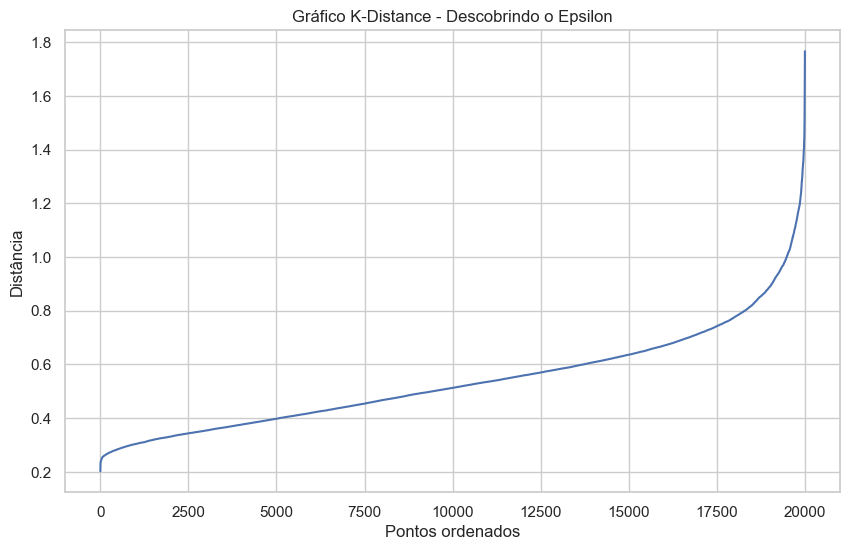

In [18]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

vizinhos = NearestNeighbors(n_neighbors=12)
vizinhos_fit = vizinhos.fit(df_pca) # Usando o seu df_pca!

distancias, indices = vizinhos_fit.kneighbors(df_pca)

distancias = np.sort(distancias[:, 11], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distancias)
plt.title('Gráfico K-Distance - Descobrindo o Epsilon')
plt.ylabel('Distância')
plt.xlabel('Pontos ordenados')
plt.grid(True)
plt.show()

### 2.2 Teste Inicial de Epsilon
Teste exploratório com eps=0.55 para observar o comportamento inicial do algoritmo.

In [19]:
from sklearn.cluster import DBSCAN
import numpy as np


meu_epsilon = 0.55
meu_min_samples = 12

dbscan = DBSCAN(eps=meu_epsilon, min_samples=meu_min_samples)


clusters_dbscan = dbscan.fit_predict(df_pca)


total_pontos = len(clusters_dbscan)
ruido = list(clusters_dbscan).count(-1)
proporcao_ruido = (ruido / total_pontos) * 100


numero_de_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)

print(f"Parâmetros: eps={meu_epsilon} | min_samples={meu_min_samples}")
print("-" * 40)
print(f"Número de clusters reais encontrados: {numero_de_clusters}")
print(f"Pontos classificados como ruído (-1): {ruido} usuários ({proporcao_ruido:.2f}% da base)")

Parâmetros: eps=0.55 | min_samples=12
----------------------------------------
Número de clusters reais encontrados: 17
Pontos classificados como ruído (-1): 4809 usuários (24.04% da base)


### 2.3 Calibração — Teste de Múltiplos Epsilon

In [20]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd


eps_testes = [0.60, 0.70, 0.85, 1.0, 1.2, 1.5]
meu_min_samples = 12

resultados = []

for eps_atual in eps_testes:
    dbscan = DBSCAN(eps=eps_atual, min_samples=meu_min_samples)
    clusters = dbscan.fit_predict(df_pca)

    total = len(clusters)
    ruido = list(clusters).count(-1)
    perc_ruido = (ruido / total) * 100
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

    resultados.append({
        'Epsilon': eps_atual,
        'Clusters Reais': n_clusters,
        'Ruído (%)': round(perc_ruido, 2)
    })


df_resultados = pd.DataFrame(resultados)
print("--- TESTE DE MÚLTIPLOS EPSILON ---")
print(df_resultados.to_string(index=False))

--- TESTE DE MÚLTIPLOS EPSILON ---
 Epsilon  Clusters Reais  Ruído (%)
    0.60              10      15.27
    0.70               5       6.04
    0.85               3       1.85
    1.00               2       0.53
    1.20               2       0.06
    1.50               1       0.00


### 2.4 Modelo DBSCAN Final

In [21]:

dbscan_final = DBSCAN(eps=0.70, min_samples=12)
labels_finais = dbscan_final.fit_predict(df_pca)


df_final = df_modelo.copy()
df_final['Cluster_DBSCAN'] = labels_finais


df_personas = df_final[df_final['Cluster_DBSCAN'] != -1]


perfil_grupos = df_personas.groupby('Cluster_DBSCAN').agg(
    Tamanho_do_Grupo=('Cluster_DBSCAN', 'count'),
    # Se quiser ver a média de todas as colunas, use a linha abaixo:
    **{col: (col, 'mean') for col in df_final.columns if col != 'Cluster_DBSCAN'}
).sort_values(by='Tamanho_do_Grupo', ascending=False)


print("=== PERFIL DOS 5 CLUSTERS PRINCIPAIS ===")
display(perfil_grupos.round(2).T) # O '.T' transpõe a tabela para facilitar a leitura das colunas


qtd_ruido = len(df_final[df_final['Cluster_DBSCAN'] == -1])
print(f"\nOs {qtd_ruido} usuários de ruído (-1) foram isolados para não distorcer essas médias.")

=== PERFIL DOS 5 CLUSTERS PRINCIPAIS ===


Cluster_DBSCAN,1,0,2,3,4
Tamanho_do_Grupo,9702.00,5530.00,3537.00,12.00,11.00
Rent_pct,0.20,0.30,0.15,0.15,0.30
Loan_Repayment_pct,0.05,0.05,0.04,0.00,0.00
Disposable_pct,0.28,0.18,0.33,0.34,0.27
Desired_Savings_pct,0.09,0.09,0.09,0.23,0.23
Age,41.00,41.05,41.07,41.75,35.64
Dependents,1.99,2.03,2.00,3.83,0.00
Gap_Poupanca,-0.18,-0.08,-0.24,-0.11,-0.04
City_Tier_enc,2.00,3.00,1.00,1.00,3.00
Gastos_Consumo_pct,0.20,0.20,0.20,0.20,0.20



Os 1208 usuários de ruído (-1) foram isolados para não distorcer essas médias.


### 2.5 Distribuição e Projeção Espacial dos Clusters

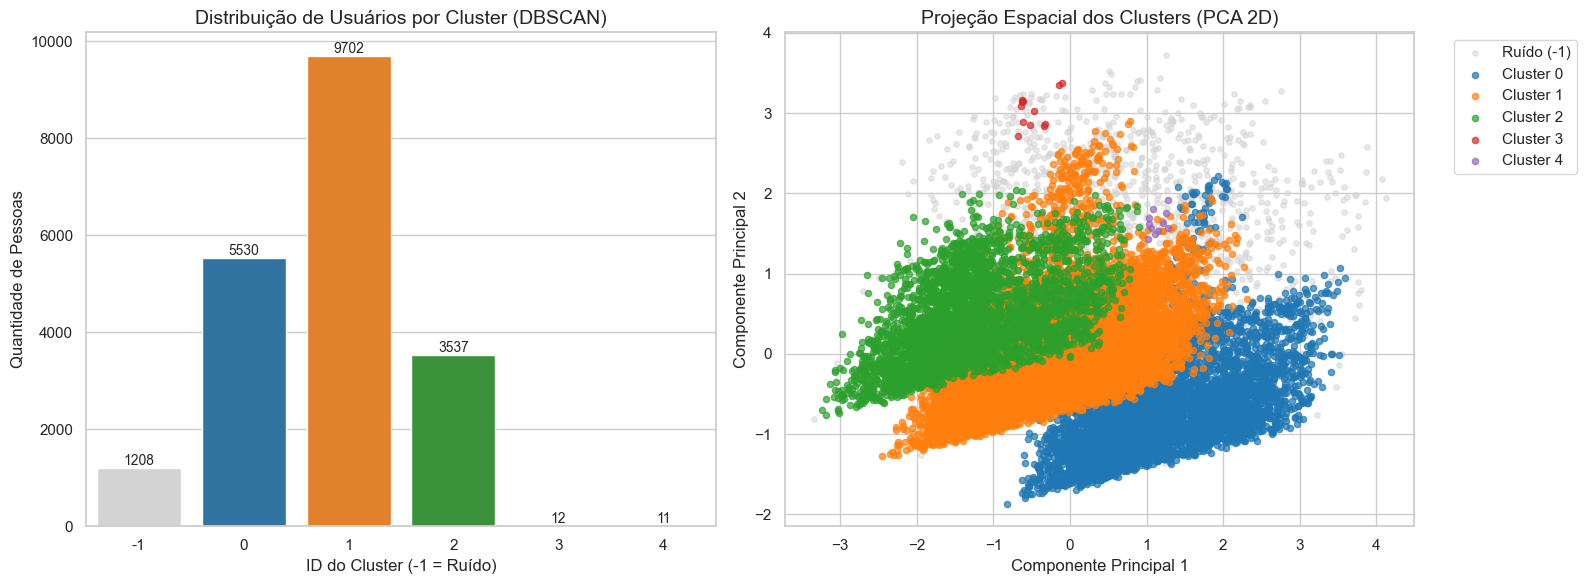

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual padrão
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- GRÁFICO 1: Volumetria (Tamanho de cada cluster) ---
plt.subplot(1, 2, 1)

# Extraímos os clusters únicos em formato original (inteiro)
clusters_unicos = sorted(df_final['Cluster_DBSCAN'].unique())

# Correção: Construímos a paleta forçando as chaves a serem strings (texto)
paleta = {str(c): ('#d3d3d3' if c == -1 else sns.color_palette("tab10")[c % 10]) for c in clusters_unicos}

# Correção: Transformamos a coluna em string temporariamente na hora de plotar e adicionamos o 'hue'
df_final['Cluster_str'] = df_final['Cluster_DBSCAN'].astype(str)
ax = sns.countplot(
    data=df_final,
    x='Cluster_str',
    hue='Cluster_str',
    palette=paleta,
    legend=False,
    order=[str(c) for c in clusters_unicos] # Mantém a ordem numérica do menor para o maior
)

plt.title('Distribuição de Usuários por Cluster (DBSCAN)', fontsize=14)
plt.xlabel('ID do Cluster (-1 = Ruído)', fontsize=12)
plt.ylabel('Quantidade de Pessoas', fontsize=12)

# Adicionando os números em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

# --- GRÁFICO 2: Dispersão Espacial (Usando as componentes do PCA) ---
plt.subplot(1, 2, 2)

# Plotando primeiro o Ruído
plt.scatter(df_pca[df_final['Cluster_DBSCAN'] == -1, 0],
            df_pca[df_final['Cluster_DBSCAN'] == -1, 1],
            c='#d3d3d3', label='Ruído (-1)', alpha=0.5, s=15)

# Plotando os Clusters Reais
for c in clusters_unicos:
    if c != -1:
        # Puxamos a cor usando a versão string do cluster
        plt.scatter(df_pca[df_final['Cluster_DBSCAN'] == c, 0],
                    df_pca[df_final['Cluster_DBSCAN'] == c, 1],
                    c=[paleta[str(c)]], label=f'Cluster {c}', alpha=0.7, s=20)

plt.title('Projeção Espacial dos Clusters (PCA 2D)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 2.7 Validação: Silhouette Diagram

Avaliação da qualidade dos clusters para diferentes valores de epsilon, excluindo o ruído do cálculo. A linha vermelha representa o coeficiente médio — clusters com área predominantemente à direita dela são bem formados.

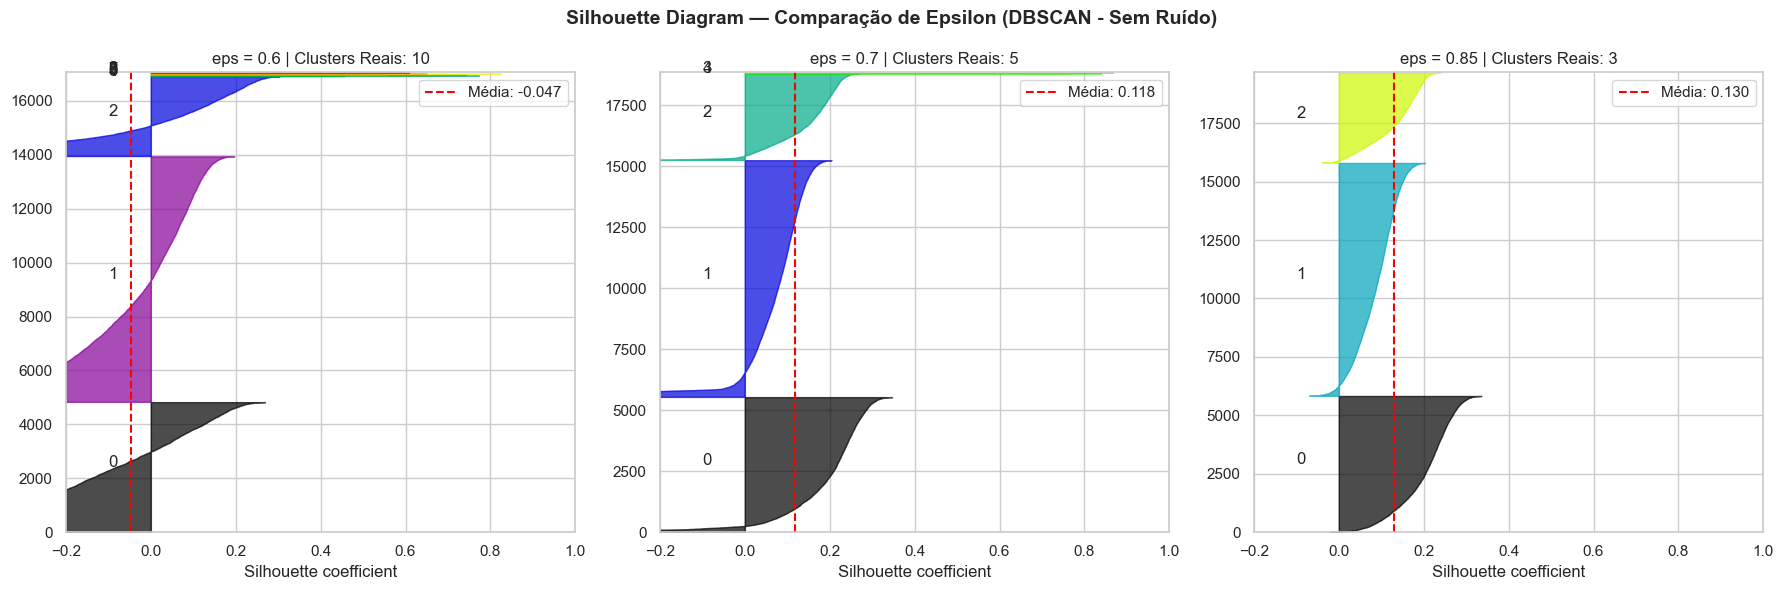

In [23]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

def plot_silhouette_dbscan(X, labels, ax, eps_val):
    """
    Plota o diagrama de silhueta ignorando o ruído (-1).
    """
    # Filtra os dados: removemos o ruído para avaliar apenas os agrupamentos reais
    mascara_sem_ruido = labels != -1
    X_limpo = X[mascara_sem_ruido]
    labels_limpos = labels[mascara_sem_ruido]

    # Se não formou pelo menos 2 clusters reais, a silhueta não pode ser calculada
    n_clusters_reais = len(set(labels_limpos))
    if n_clusters_reais < 2:
        ax.set_title(f'eps = {eps_val} (Falhou: < 2 clusters)')
        ax.axis('off') # Desliga o eixo se não houver clusters suficientes
        return

    # Calcula a silhueta apenas para os dados agrupados
    sil_vals = silhouette_samples(X_limpo, labels_limpos)

    ax.set_xlim([-0.2, 1])
    ax.set_ylim([0, len(X_limpo) + (n_clusters_reais + 1) * 10])

    y_lower = 10

    # Pega as labels únicas e ordenadas (ex: 0, 1, 2...)
    clusters_unicos = np.unique(labels_limpos)

    for idx, c in enumerate(clusters_unicos):
        cluster_vals = np.sort(sil_vals[labels_limpos == c])
        size_cluster = cluster_vals.shape[0]
        y_upper = y_lower + size_cluster

        # Cor baseada no índice para ficar organizado
        color = cm.nipy_spectral(float(idx) / n_clusters_reais)

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)

        # Coloca a label original do cluster ao lado da área colorida
        ax.text(-0.1, y_lower + 0.5 * size_cluster, str(c))
        y_lower = y_upper + 10

    avg = sil_vals.mean()
    ax.axvline(x=avg, color="red", linestyle="--", label=f'Média: {avg:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_title(f'eps = {eps_val} | Clusters Reais: {n_clusters_reais}')
    ax.legend()

# Vamos testar 3 valores de Epsilon para comparar a evolução da silhueta
eps_testes = [0.60, 0.70, 0.85] # Você pode ajustar para os valores que testou antes
meu_min_samples = 12

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, eps_atual in enumerate(eps_testes):
    # Instancia e roda o DBSCAN
    db = DBSCAN(eps=eps_atual, min_samples=meu_min_samples)
    lbl = db.fit_predict(df_pca)

    # Plota a silhueta no subplot correspondente
    plot_silhouette_dbscan(df_pca, lbl, axes[idx], eps_atual)

plt.suptitle('Silhouette Diagram — Comparação de Epsilon (DBSCAN - Sem Ruído)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Interpretabilidade — Árvore de Decisão Surrogate

Modelo substituto treinado com os labels do DBSCAN para extrair regras de separação interpretáveis entre as personas. Pontos de ruído excluídos do treinamento.

=== REGRAS DE NEGÓCIO EXTRAÍDAS ===
|--- Rent_pct <= 0.25
|   |--- City_Tier_enc <= 1.50
|   |   |--- Desired_Savings_pct <= 0.20
|   |   |   |--- class: 2
|   |   |--- Desired_Savings_pct >  0.20
|   |   |   |--- class: 3
|   |--- City_Tier_enc >  1.50
|   |   |--- class: 1
|--- Rent_pct >  0.25
|   |--- Desired_Savings_pct <= 0.22
|   |   |--- class: 0
|   |--- Desired_Savings_pct >  0.22
|   |   |--- Gap_Poupanca <= -0.02
|   |   |   |--- class: 4
|   |   |--- Gap_Poupanca >  -0.02
|   |   |   |--- class: 0



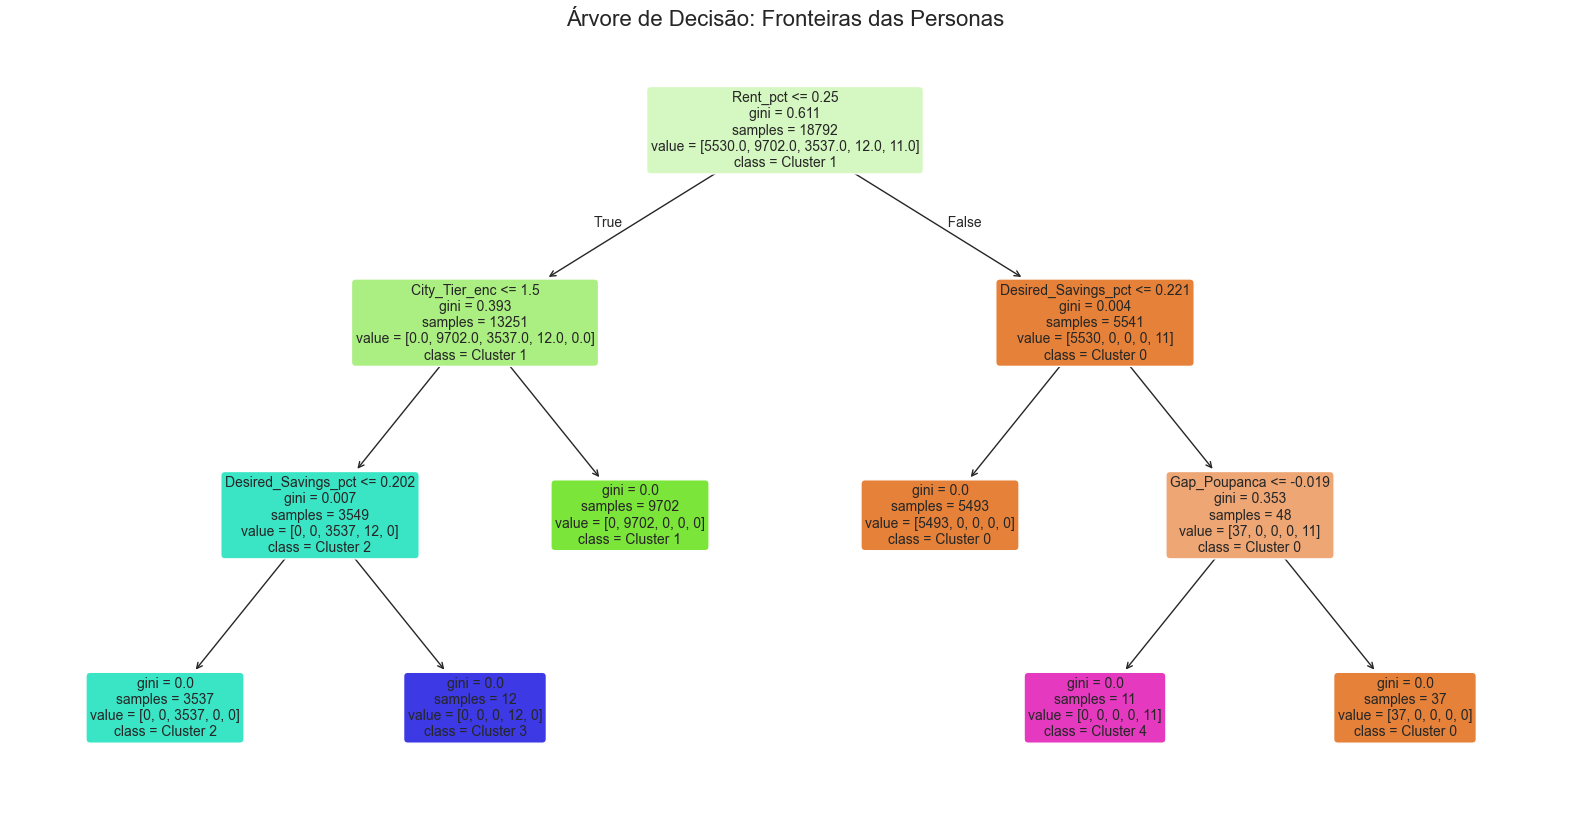

In [24]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

#Preparar os dados (Remover o ruído -1)
#Usamos o df_modelo, pois ele contém as variáveis proporcionais que explicam o comportamento
df_limpo = df_modelo[df_final['Cluster_DBSCAN'] != -1].copy()
y_alvo = df_final[df_final['Cluster_DBSCAN'] != -1]['Cluster_DBSCAN']

#Instanciar e treinar a Árvore de Decisão
max_depth=4 #garante que as regras fiquem simples e diretas
arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore.fit(df_limpo, y_alvo)

#Exportar as Regras em Texto (Excelente para ler e documentar)
regras_texto = export_text(arvore, feature_names=list(df_limpo.columns))
print("=== REGRAS DE NEGÓCIO EXTRAÍDAS ===")
print(regras_texto)

#Plotar a Árvore Visualmente
plt.figure(figsize=(20, 10))
plot_tree(arvore,
          feature_names=df_limpo.columns,
          class_names=[f'Cluster {c}' for c in sorted(y_alvo.unique())],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árvore de Decisão: Fronteiras das Personas', fontsize=16)
plt.show()

### 2.8 Princípio de Pareto: Comprometimento Financeiro

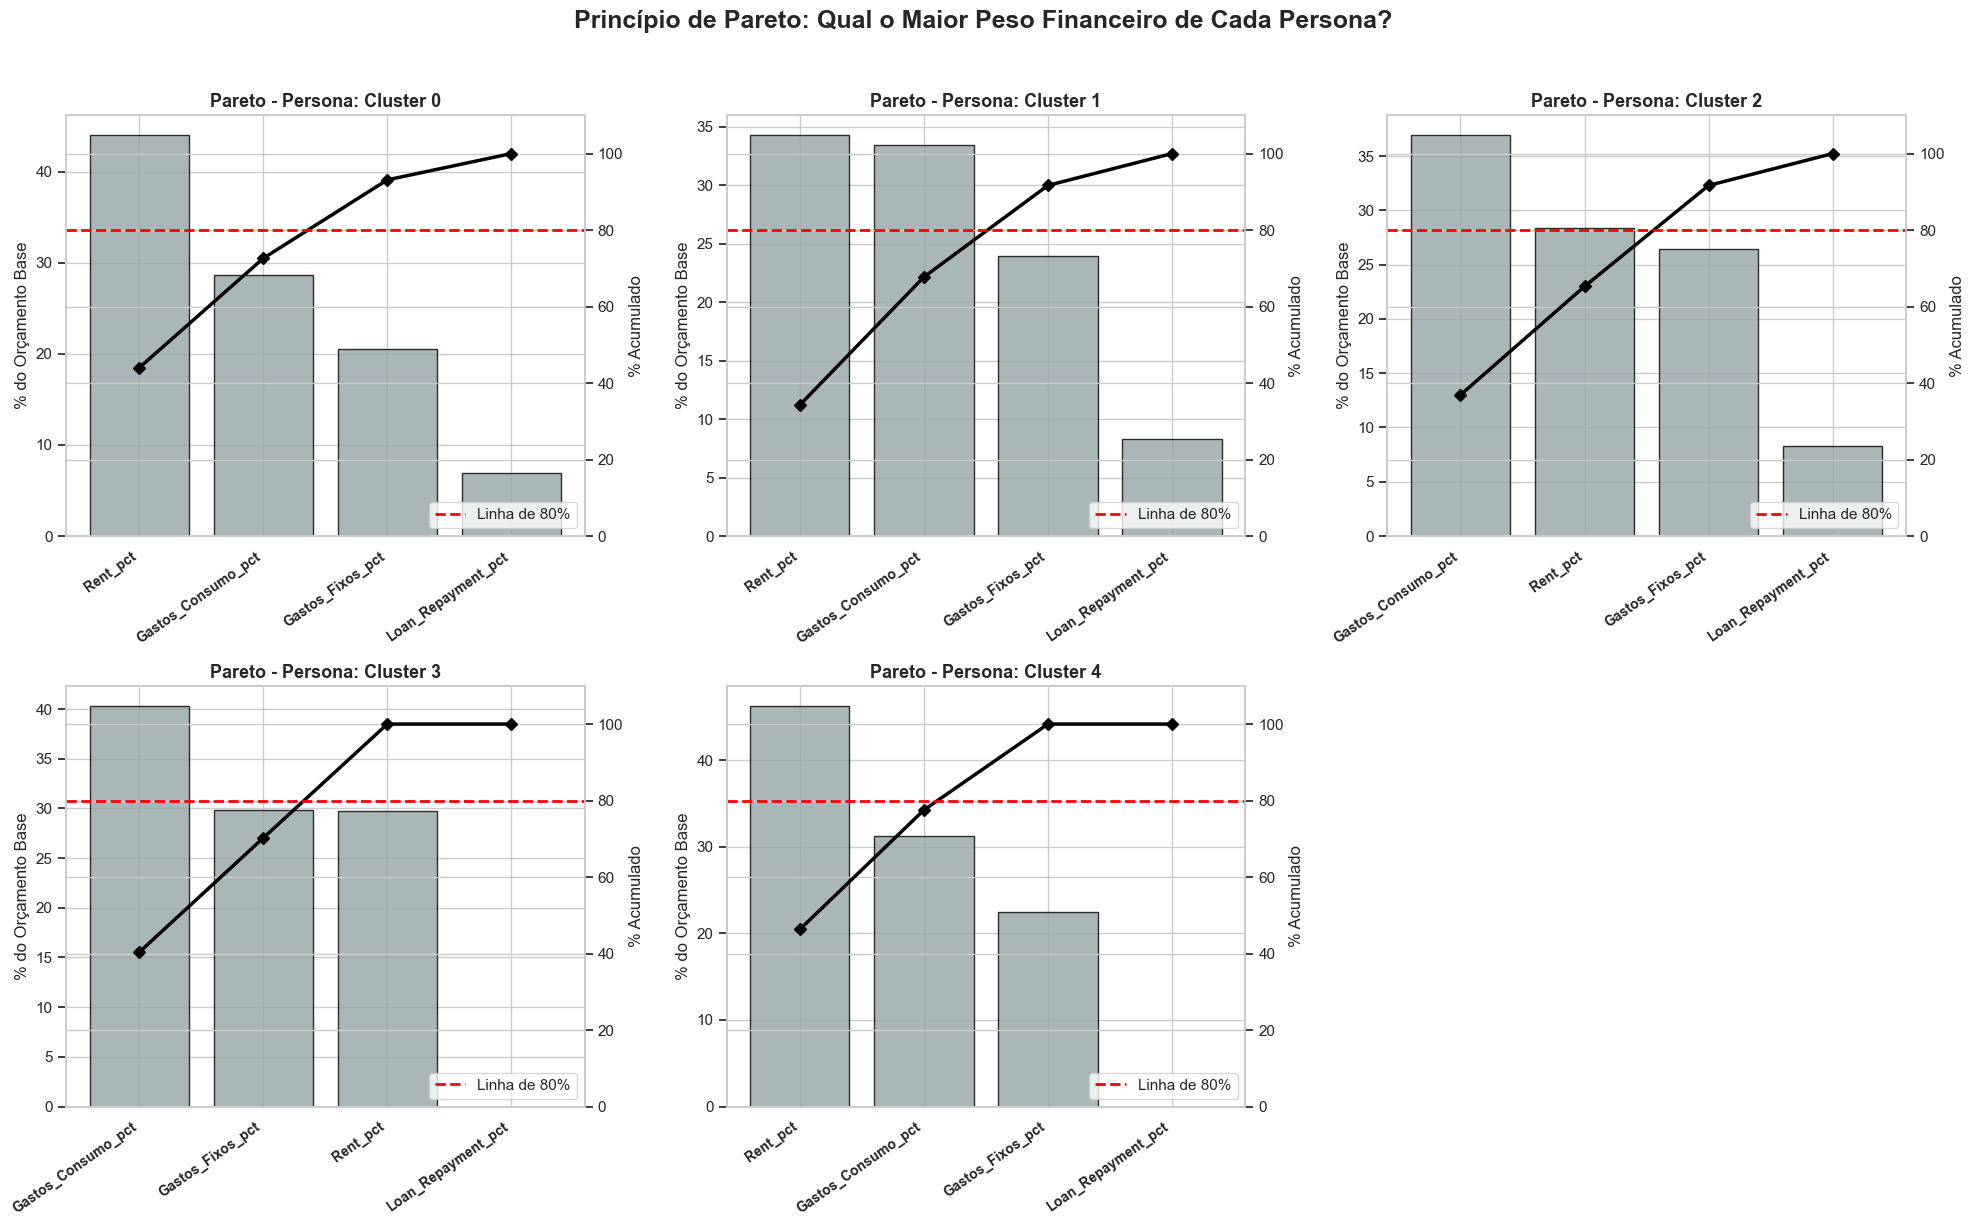

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Garantir que os rótulos do DBSCAN estejam no seu df_modelo
df_modelo['Cluster_DBSCAN'] = df_final['Cluster_DBSCAN']

# 2. As 4 grandes fatias do orçamento que queremos analisar
colunas_pareto = ['Rent_pct', 'Loan_Repayment_pct',
                  'Gastos_Consumo_pct', 'Gastos_Fixos_pct']

# Filtramos os 5 clusters reais (excluindo o ruído -1)
clusters_reais = [0, 1, 2, 3, 4]

# 3. Configuração do Grid de Gráficos (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, cluster_id in enumerate(clusters_reais):
    # Pega as médias das 4 colunas apenas para os usuários deste cluster específico
    dados_cluster = df_modelo[df_modelo['Cluster_DBSCAN'] == cluster_id][colunas_pareto].mean()

    # Ordena os gastos do maior para o menor peso
    dados_sorted = dados_cluster.abs().sort_values(ascending=False)

    # Converte os valores para representar 100% daquele pedaço do orçamento
    percentual = dados_sorted / dados_sorted.sum() * 100
    cumulativo = percentual.cumsum()

    # --- Plotagem Individual do Subplot ---
    ax = axes[i]

    # AQUI: Mudamos a cor para um cinza neutro e profissional
    ax.bar(range(len(percentual)), percentual, color='#95a5a6', alpha=0.8, edgecolor='black')

    # Eixo secundário (A linha do Pareto)
    ax2 = ax.twinx()
    ax2.plot(range(len(cumulativo)), cumulativo, color='black', marker='D', linewidth=2.5)

    # A linha de corte de 80%
    ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='Linha de 80%')

    # Formatação do Subplot
    ax.set_xticks(range(len(percentual)))
    ax.set_xticklabels(percentual.index, rotation=35, ha='right', fontsize=10, fontweight='bold')
    ax.set_title(f'Pareto - Persona: Cluster {cluster_id}', fontweight='bold', fontsize=13)
    ax.set_ylabel('% do Orçamento Base')
    ax2.set_ylabel('% Acumulado')
    ax2.set_ylim(0, 110)
    ax2.legend(loc='lower right')

# Como temos 5 clusters e 6 espaços no grid, escondemos o último quadro vazio
axes[5].set_visible(False)

plt.suptitle('Princípio de Pareto: Qual o Maior Peso Financeiro de Cada Persona?',
             size=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.9 Interpretabilidade — SHAP Values

#### 2.9.1 Beeswarm por Classe
Importância das variáveis para uma persona específica — mostra direção e magnitude do impacto de cada feature na separação daquele cluster.

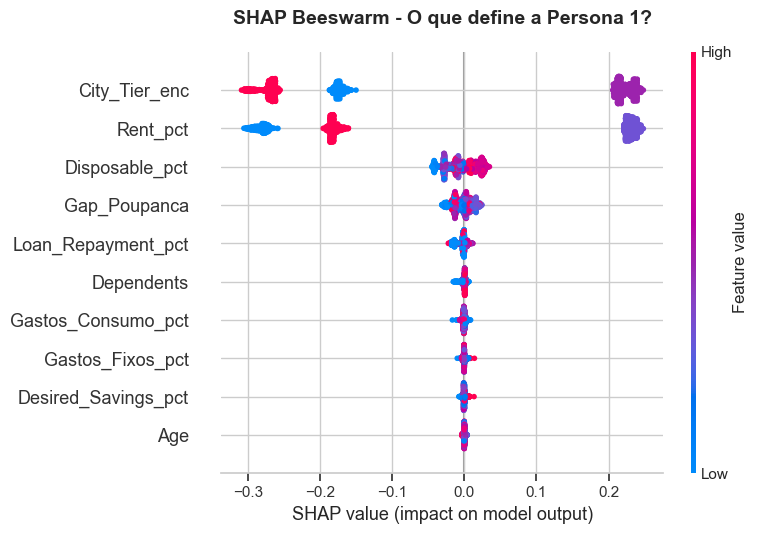

In [26]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

#Limpeza rigorosa: Remover QUALQUER coluna de cluster para evitar vazamento
colunas_para_remover = ['Cluster_DBSCAN', 'Cluster']
df_limpo = df_modelo[df_modelo['Cluster_DBSCAN'] != -1].copy()

y_alvo = df_limpo['Cluster_DBSCAN']
X = df_limpo.drop(columns=[col for col in colunas_para_remover if col in df_limpo.columns])

#Amostragem
tamanho_amostra = min(2000, len(X))
X_sample = X.sample(n=tamanho_amostra, random_state=42)
y_sample = y_alvo.loc[X_sample.index]

#Treinar o modelo Substituto
rf_surrogate = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_surrogate.fit(X_sample, y_sample)

#Calcular os valores SHAP
explainer = shap.TreeExplainer(rf_surrogate)
shap_values = explainer.shap_values(X_sample)

#Tratamento de Versões da Biblioteca SHAP (A CORREÇÃO DO ERRO)
classe_alvo = 1

#O código agora verifica o formato geométrico da resposta do SHAP antes de fatiar
if isinstance(shap_values, list):
    # Se for versão antiga (lista de matrizes 2D)
    shap_valores_finais = shap_values[classe_alvo]
elif len(shap_values.shape) == 3:
    # Se for versão nova (matriz 3D: amostras, features, classes)
    shap_valores_finais = shap_values[:, :, classe_alvo]
else:
    # Fallback de segurança
    shap_valores_finais = shap_values

#Plotagem Focada (Visão de Negócio)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_valores_finais,
    X_sample,
    feature_names=X_sample.columns,
    plot_type='dot',
    show=False
)

plt.title(f'SHAP Beeswarm - O que define a Persona {classe_alvo}?', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### 2.9.2 Bar Global Multiclasse
Visão agregada de todas as personas — quais variáveis mais contribuem globalmente para a separação entre clusters.

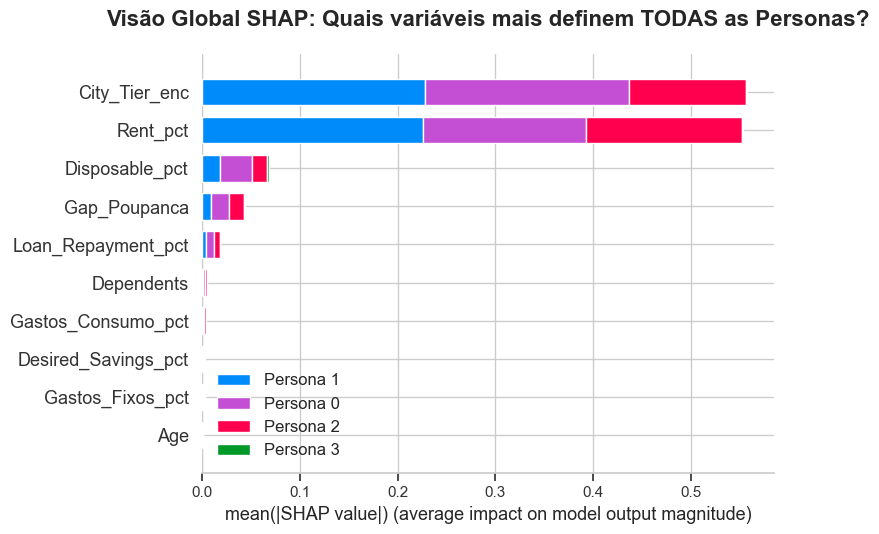

In [27]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

#Limpeza rigorosa (Evitando o vazamento de dados)
colunas_para_remover = ['Cluster_DBSCAN', 'Cluster']
df_limpo = df_modelo[df_modelo['Cluster_DBSCAN'] != -1].copy()

y_alvo = df_limpo['Cluster_DBSCAN']
X = df_limpo.drop(columns=[col for col in colunas_para_remover if col in df_limpo.columns])

#Amostragem
tamanho_amostra = min(2000, len(X))
X_sample = X.sample(n=tamanho_amostra, random_state=42)
y_sample = y_alvo.loc[X_sample.index]

#Treinar o modelo Substituto
rf_surrogate = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_surrogate.fit(X_sample, y_sample)

#Calcular os valores SHAP
explainer = shap.TreeExplainer(rf_surrogate)
shap_values = explainer.shap_values(X_sample)

#Tratamento universal para garantir que o SHAP entenda as múltiplas classes
#O plot tipo 'bar' multiclasse exige uma lista de matrizes 2D
if not isinstance(shap_values, list) and len(shap_values.shape) == 3:
    # Se a biblioteca retornou o formato novo (matriz 3D), convertemos para lista
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_values_list = shap_values

#Pegar os nomes das personas ordenados
nomes_personas = [f"Persona {c}" for c in sorted(y_alvo.unique())]

#Plotagem Global: Gráfico de Barras Empilhadas (O padrão ouro para multiclasse)
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values_list,
    X_sample,
    feature_names=X_sample.columns,
    plot_type='bar',
    class_names=nomes_personas, # Adiciona a legenda bonita
    show=False
)

plt.title('Visão Global SHAP: Quais variáveis mais definem TODAS as Personas?',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### 2.9.3 Beeswarm Global
Importância global das variáveis com direção de impacto — média sobre todas as classes.

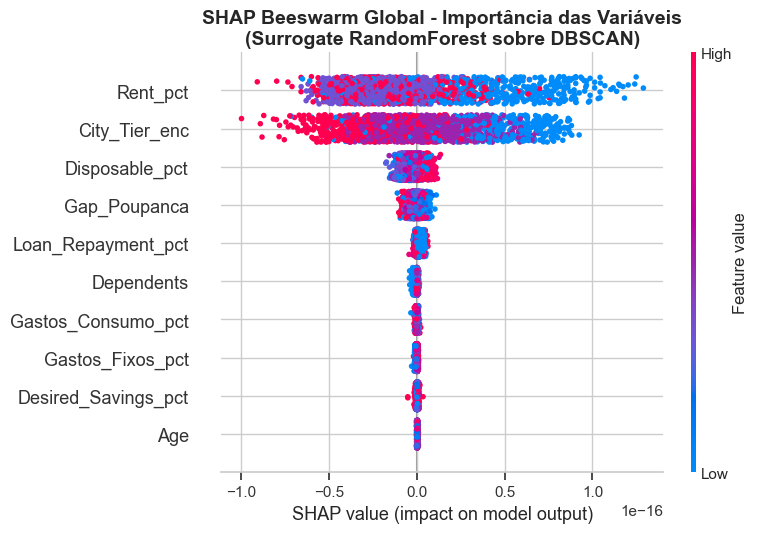

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

#Preparação dos dados do DBSCAN (Removendo ruído e evitando vazamento)
colunas_para_remover = ['Cluster_DBSCAN', 'Cluster']
df_limpo = df_modelo[df_modelo['Cluster_DBSCAN'] != -1].copy()

y_alvo = df_limpo['Cluster_DBSCAN']
X = df_limpo.drop(columns=[col for col in colunas_para_remover if col in df_limpo.columns])
feature_names = X.columns

#Amostragem para performance do SHAP
tamanho_amostra = min(2000, len(X))
X_sample = X.sample(n=tamanho_amostra, random_state=42)
y_sample = y_alvo.loc[X_sample.index]

#Treinamento do Modelo Substituto
rf_surrogate = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_surrogate.fit(X_sample, y_sample)

#Cálculo dos valores SHAP
explainer = shap.TreeExplainer(rf_surrogate)
shap_values = explainer.shap_values(X_sample)

#Tratamento de eixos para o Beeswarm Global
#Garantindo que a matriz tenha o formato (n_samples, n_features, n_classes)
#para que o seu mean(axis=2) funcione sem dar erro de "AssertionError"
if isinstance(shap_values, list):
    # Se a biblioteca retornar uma lista, convertemos e transpomos
    shap_values_array = np.transpose(np.array(shap_values), (1, 2, 0))
else:
    # Se já retornar um array 3D nas versões mais recentes
    shap_values_array = np.array(shap_values)

#Média sobre as classes para mostrar impacto geral (Exatamente como no seu K-Means)
shap_mean = shap_values_array.mean(axis=2)

#Plotagem Beeswarm Global
plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_mean,
    X_sample,
    feature_names=feature_names,
    plot_type='dot',
    show=False,
    color_bar=True
)
plt.title('SHAP Beeswarm Global - Importância das Variáveis\n(Surrogate RandomForest sobre DBSCAN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.10 Radar Chart — Perfil Comportamental por Persona

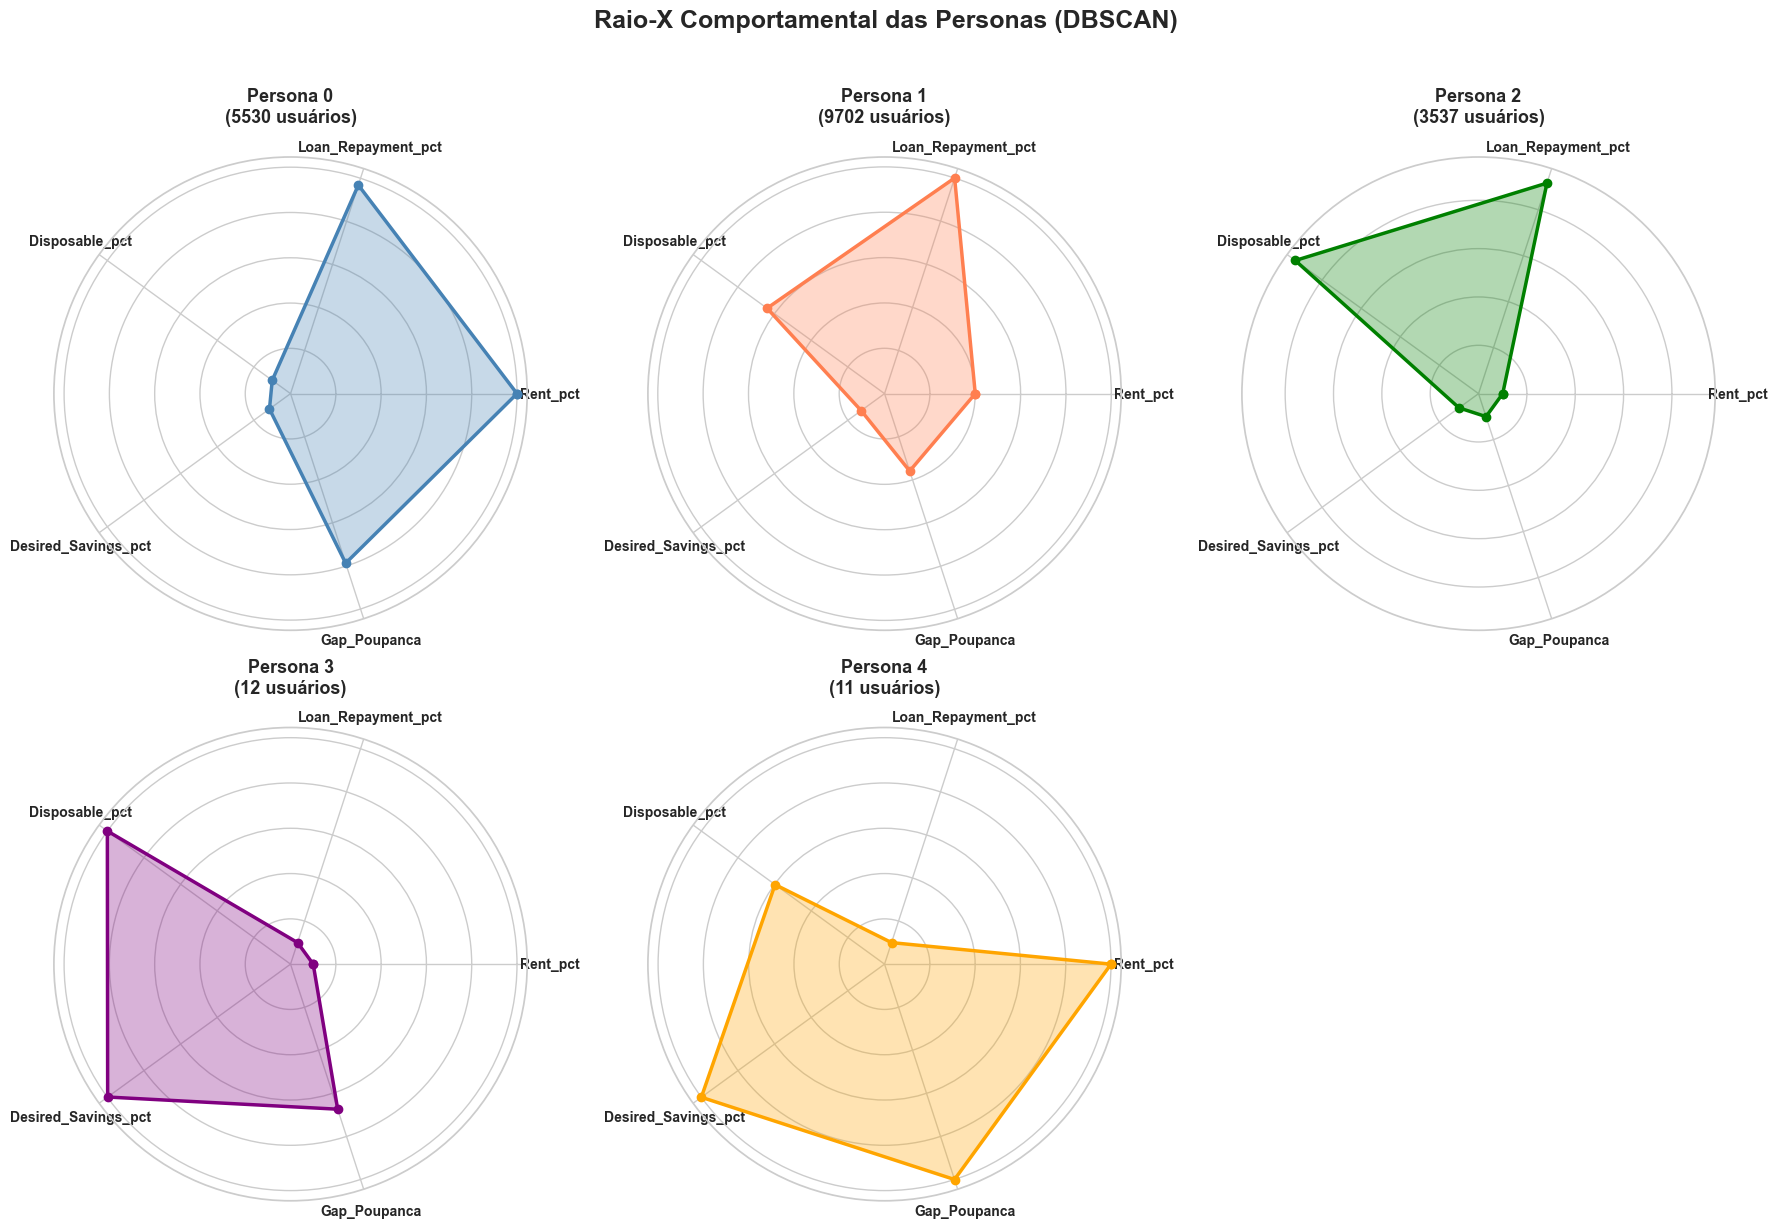

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Definir as categorias do Radar
categorias_radar = ['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct',
                    'Desired_Savings_pct', 'Gap_Poupanca']

# 2. Filtrar o ruído (-1) e calcular a média (perfil) e contagem de cada cluster real
df_limpo = df_modelo[df_modelo['Cluster_DBSCAN'] != -1]
perfil_clusters = df_limpo.groupby('Cluster_DBSCAN')[categorias_radar].mean()
contagem = df_limpo['Cluster_DBSCAN'].value_counts().sort_index()

# 3. Normalização (MinMaxScaler) corrigida para comparar colunas (variáveis)
# O range (0.1, 1.0) evita que o menor valor suma no centro do gráfico (fique invisível)
scaler_radar = MinMaxScaler(feature_range=(0.1, 1.0))

# Sem a transposição, garantimos que o eixo de 'Rent' compare apenas 'Rent' entre os clusters
perfil_norm = pd.DataFrame(
    scaler_radar.fit_transform(perfil_clusters),
    index=perfil_clusters.index,
    columns=perfil_clusters.columns
)

# 4. Configuração da geometria do Radar (Ângulos e fechamento do polígono)
N = len(categorias_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 5. Configuração do Grid de Gráficos (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

# Cores originais do seu projeto
cores = ['steelblue', 'coral', 'green', 'purple', 'orange']

# 6. Loop de plotagem dos 5 clusters
for i, cluster_id in enumerate(perfil_clusters.index):
    # Extrai os valores normalizados e duplica o primeiro no final para fechar o desenho
    valores = perfil_norm.loc[cluster_id].values.tolist()
    valores += valores[:1]

    # Desenha a linha e preenche o interior
    axes[i].plot(angles, valores, 'o-', linewidth=2.5, color=cores[i])
    axes[i].fill(angles, valores, alpha=0.3, color=cores[i])

    # Coloca os nomes das variáveis nas pontas do radar
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(categorias_radar, size=10, fontweight='bold')

    # Oculta os círculos numéricos internos (eixo Y) para um visual mais limpo e moderno
    axes[i].set_yticklabels([])

    # Título individual com a volumetria
    axes[i].set_title(f'Persona {cluster_id}\n({contagem[cluster_id]} usuários)',
                      size=13, fontweight='bold', pad=25)

# 7. Ocultar o 6º gráfico que sobra no grid
axes[5].set_visible(False)

plt.suptitle('Raio-X Comportamental das Personas (DBSCAN)', size=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.11 Relatório de Personas — Visão de Negócio

Geração do relatório textual com o DNA demográfico e financeiro de cada persona, exportado para arquivo `.txt`.

In [30]:
import pandas as pd
import numpy as np

df_limpo = df_modelo[df_modelo['Cluster_DBSCAN'] != -1].copy()
total_usuarios = len(df_limpo)
clusters_reais = sorted(df_limpo['Cluster_DBSCAN'].unique())

# --- O SEU DICIONÁRIO DE RÓTULOS SOCIAIS ---
# Edite os textos abaixo conforme a sua leitura final dos dados!
rotulos_sociais = {
    0: "O Estabelecido da Metrópole (Conforto e Família)",
    1: "O Sobrevivente Urbano (A Massa Normativa/Trabalhadora)",
    2: "O Refém do Orçamento (Alto Risco / Endividado)",
    3: "O Poupador Agressivo (Visão de Futuro / Investidor)",
    4: "O Perfil Despreocupado (Alto Consumo Supérfluo)"
}

# Abrindo um arquivo de texto para salvar o relatório completo
with open('relatorio_personas_com_rotulos.txt', 'w', encoding='utf-8') as arquivo:

    arquivo.write("="*65 + "\n")
    arquivo.write(" 🧠 RELATÓRIO DE PERSONAS (THINKMONEY) - VISÃO DE NEGÓCIO 🧠\n")
    arquivo.write("="*65 + "\n")

    for c in clusters_reais:
        dados_c = df_limpo[df_limpo['Cluster_DBSCAN'] == c]

        tamanho = len(dados_c)
        percentual = (tamanho / total_usuarios) * 100

        tier_dominante = dados_c['City_Tier_enc'].mode()[0]
        idade_media = dados_c['Age'].mean()
        dependentes_med = dados_c['Dependents'].median()

        aluguel_med = dados_c['Rent_pct'].mean() * 100
        divida_med = dados_c['Loan_Repayment_pct'].mean() * 100
        renda_livre = dados_c['Disposable_pct'].mean() * 100
        gap_med = dados_c['Gap_Poupanca'].mean() * 100

        gastos = dados_c[['Rent_pct', 'Loan_Repayment_pct', 'Gastos_Consumo_pct', 'Gastos_Fixos_pct']].mean()
        top_gastos = gastos.sort_values(ascending=False).head(2)

        # Puxa o rótulo do dicionário (ou um genérico se não encontrar)
        rotulo = rotulos_sociais.get(c, "Perfil em Análise")

        # O cabeçalho agora traz o Rótulo Social com muito destaque
        arquivo.write(f"\n🔹 PERSONA {c} | {rotulo}\n")
        arquivo.write(f"   Volumetria: {tamanho} usuários ({percentual:.1f}% da base válida)\n")
        arquivo.write("-" * 65 + "\n")

        arquivo.write(f"🧬 DNA Demográfico:\n")
        arquivo.write(f"   • Tier da Cidade (Moda): Nível {int(tier_dominante)}\n")
        arquivo.write(f"   • Idade Média: {idade_media:.0f} anos\n")
        arquivo.write(f"   • Dependentes (Mediana): {int(dependentes_med)}\n")

        arquivo.write(f"\n💸 Raio-X do Bolso (Média do Orçamento):\n")
        arquivo.write(f"   • Peso do Aluguel: {aluguel_med:.1f}%\n")
        arquivo.write(f"   • Peso de Empréstimos: {divida_med:.1f}%\n")
        arquivo.write(f"   • Renda Livre: {renda_livre:.1f}%\n")

        status_gap = "Frustrado (Guarda menos que a meta)" if gap_med > 0 else "Confortável (Guarda além da meta)"
        arquivo.write(f"   • Comportamento de Poupança: {status_gap} (Gap médio: {gap_med:.1f}%)\n")

        arquivo.write(f"\n🚨 Foco de Produto (Top 2 Ralos Financeiros):\n")
        for nome, valor in top_gastos.items():
            arquivo.write(f"   • {nome}: {valor*100:.1f}% do orçamento\n")

        arquivo.write("="*65 + "\n")

print("✅ Sucesso! O relatório com os rótulos sociais foi salvo no arquivo 'relatorio_personas_com_rotulos.txt'.")

✅ Sucesso! O relatório com os rótulos sociais foi salvo no arquivo 'relatorio_personas_com_rotulos.txt'.


### 2.12 Limpeza — Remoção de Colunas Temporárias

Remove colunas auxiliares adicionadas ao df_modelo durante o DBSCAN para não contaminar o Bloco 3.

In [31]:
# Remove colunas do DBSCAN do df_modelo para não contaminar o K-Means
df_modelo.drop(columns=[c for c in ['Cluster_DBSCAN', 'Cluster_str']
                         if c in df_modelo.columns], inplace=True)
print("Colunas removidas. df_modelo limpo para o Bloco 3.")
print(f"Colunas atuais: {df_modelo.columns.tolist()}")

Colunas removidas. df_modelo limpo para o Bloco 3.
Colunas atuais: ['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct', 'Desired_Savings_pct', 'Age', 'Dependents', 'Gap_Poupanca', 'City_Tier_enc', 'Gastos_Consumo_pct', 'Gastos_Fixos_pct']



## Bloco 3 — K-Means++
### 3.1 Seleção do Número de Clusters — Elbow e Silhouette Score

Testamos K de 2 a 10 avaliando inércia (Método do Cotovelo) e Silhouette Score médio para identificar o intervalo de K candidatos.

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 11)

print("Testando valores de K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_pca, labels, sample_size=3000))
    print(f"  K={k} | Inércia: {kmeans.inertia_:.0f} | Silhouette: {silhouettes[-1]:.4f}")

print("\nConcluído!")

Testando valores de K...
  K=2 | Inércia: 64141 | Silhouette: 0.2290
  K=3 | Inércia: 56470 | Silhouette: 0.2105
  K=4 | Inércia: 51190 | Silhouette: 0.2214
  K=5 | Inércia: 46746 | Silhouette: 0.2163
  K=6 | Inércia: 42896 | Silhouette: 0.1847
  K=7 | Inércia: 40692 | Silhouette: 0.1733
  K=8 | Inércia: 39120 | Silhouette: 0.1701
  K=9 | Inércia: 37506 | Silhouette: 0.1600
  K=10 | Inércia: 36251 | Silhouette: 0.1590

Concluído!


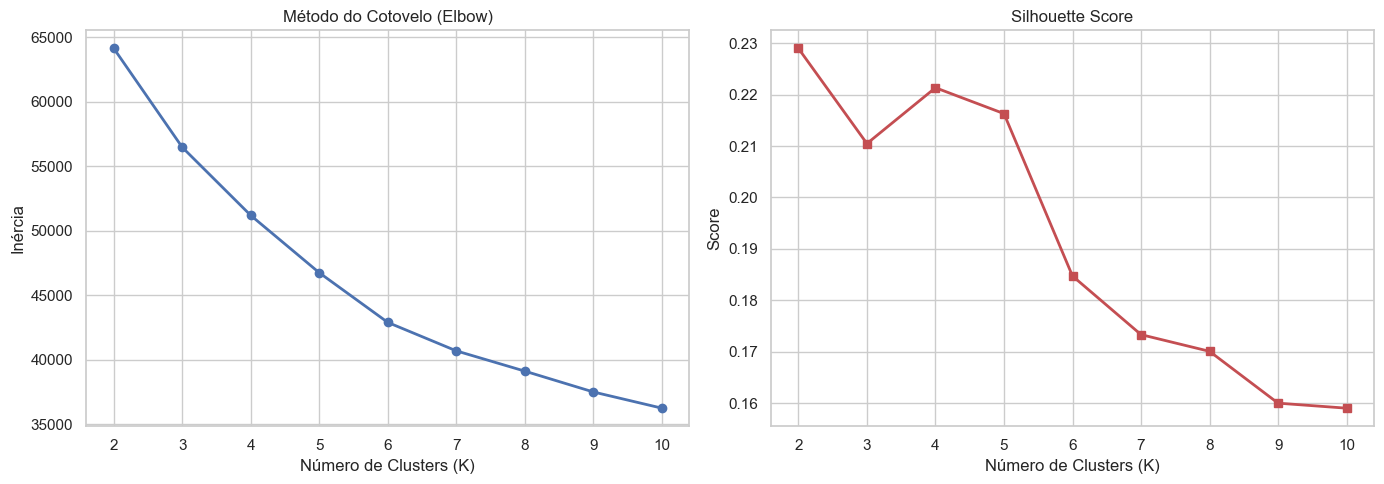

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico do Cotovelo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Método do Cotovelo (Elbow)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True)

# Gráfico Silhouette
axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3.2 Silhouette Diagram — Análise por Cluster

O Silhouette Diagram avalia a qualidade individual de cada cluster para K=3, 4 e 5. A linha vermelha representa o coeficiente médio — clusters com área predominantemente à direita são bem formados e coesos.

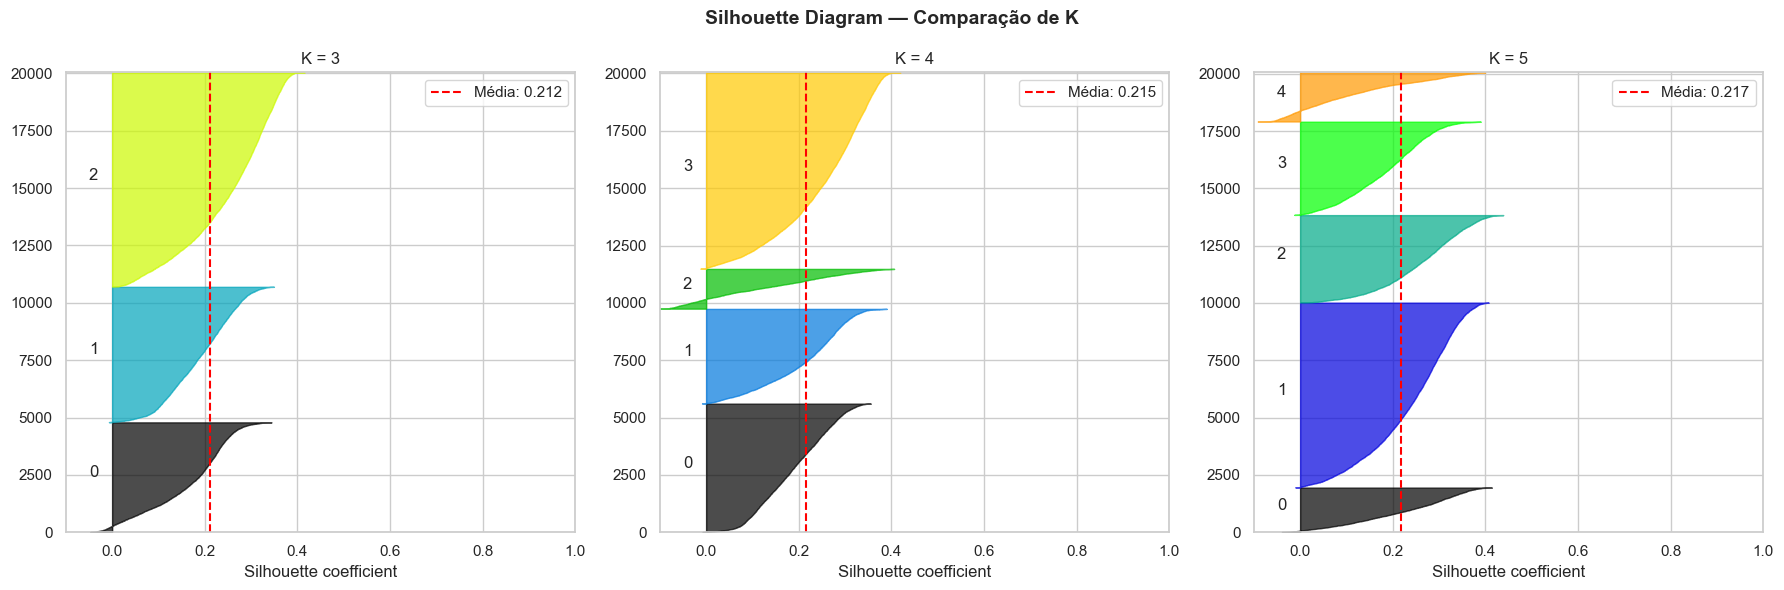

In [34]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

def plot_silhouette(X, labels, k, ax):
    sil_vals = silhouette_samples(X, labels)
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (k + 1) * 10])
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size_cluster = cluster_vals.shape[0]
        y_upper = y_lower + size_cluster
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10
    avg = sil_vals.mean()
    ax.axvline(x=avg, color="red", linestyle="--", label=f'Média: {avg:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_title(f'K = {k}')
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, k in enumerate([3, 4, 5]):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(df_pca)
    plot_silhouette(df_pca, lbl, k, axes[idx])

plt.suptitle('Silhouette Diagram — Comparação de K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Comparação de Algoritmos

Comparamos 5 algoritmos de clusterização (K-Means Random, K-Means++, Agglomerative Ward, Agglomerative Complete e Gaussian Mixture) para K ∈ {3, 4, 5}, avaliando Silhouette Score e Davies-Bouldin simultaneamente.

K-Means++ com K=5 foi selecionado como modelo final pelos seguintes critérios:
- Maior Silhouette Score entre os K testados (≈0.217)
- Distribuição mais uniforme entre clusters no Silhouette Diagram
- Estabilidade de inicialização garantindo reprodutibilidade

In [35]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

resultados_completos = []

for k in [3, 4, 5]:
    modelos = [
        ('K-Means Random', KMeans(n_clusters=k, init='random', random_state=42, n_init=10)),
        ('K-Means++', KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)),
        ('Agglomerative Ward', AgglomerativeClustering(n_clusters=k, linkage='ward')),
        ('Agglomerative Complete', AgglomerativeClustering(n_clusters=k, linkage='complete')),
        ('Gaussian Mixture', GaussianMixture(n_components=k, random_state=42)),
    ]

    for nome, modelo in modelos:
        try:
            l = modelo.fit_predict(df_pca)
            sil = silhouette_score(df_pca, l, sample_size=3000)
            db = davies_bouldin_score(df_pca, l)
            resultados_completos.append({
                'Algoritmo': nome,
                'K': k,
                'Silhouette': sil,
                'Davies-Bouldin': db
            })
        except Exception as e:
            print(f"⚠️ {nome} K={k} ignorado: {e}")

df_resultados = pd.DataFrame(resultados_completos)
df_resultados = df_resultados.sort_values(['K', 'Silhouette'], ascending=[True, False])
print(df_resultados.to_string(index=False))

             Algoritmo  K  Silhouette  Davies-Bouldin
        K-Means Random  3    0.205455        1.779478
             K-Means++  3    0.205024        1.779270
    Agglomerative Ward  3    0.203306        1.919799
Agglomerative Complete  3    0.195432        1.652312
      Gaussian Mixture  3    0.193576        1.920670
        K-Means Random  4    0.212038        1.578551
             K-Means++  4    0.209940        1.574103
    Agglomerative Ward  4    0.204484        1.616925
      Gaussian Mixture  4    0.183403        1.734332
Agglomerative Complete  4    0.152570        1.862239
        K-Means Random  5    0.216071        1.504096
             K-Means++  5    0.214900        1.504096
    Agglomerative Ward  5    0.202814        1.627246
      Gaussian Mixture  5    0.126189        1.835717
Agglomerative Complete  5    0.095319        2.106239


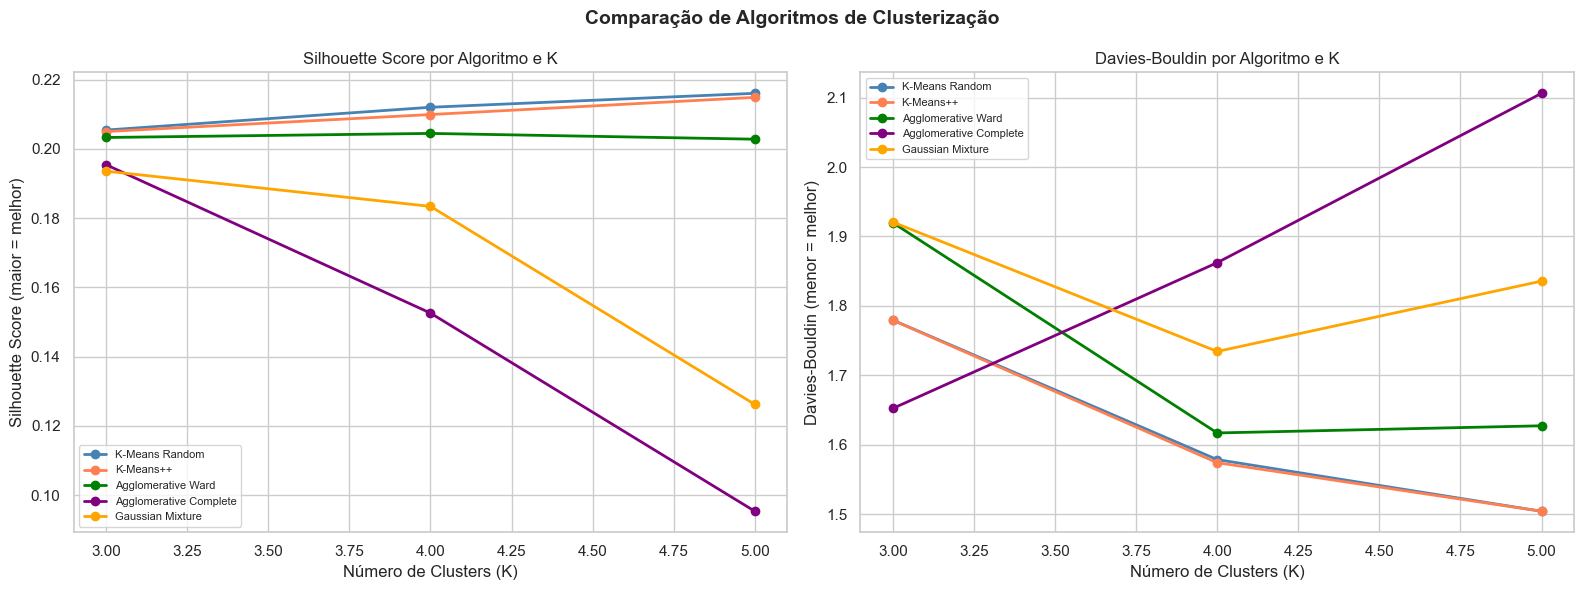

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de cores por algoritmo
cores = {
    'K-Means Random': 'steelblue',
    'K-Means++': 'coral',
    'Agglomerative Ward': 'green',
    'Agglomerative Complete': 'purple',
    'Gaussian Mixture': 'orange'
}

# --- Gráfico 1: Silhouette por K ---
for algoritmo in df_resultados['Algoritmo'].unique():
    dados = df_resultados[df_resultados['Algoritmo'] == algoritmo]
    axes[0].plot(dados['K'], dados['Silhouette'], 'o-',
                 label=algoritmo, color=cores[algoritmo], linewidth=2)

axes[0].set_title('Silhouette Score por Algoritmo e K')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Silhouette Score (maior = melhor)')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# --- Gráfico 2: Davies-Bouldin por K ---
for algoritmo in df_resultados['Algoritmo'].unique():
    dados = df_resultados[df_resultados['Algoritmo'] == algoritmo]
    axes[1].plot(dados['K'], dados['Davies-Bouldin'], 'o-',
                 label=algoritmo, color=cores[algoritmo], linewidth=2)

axes[1].set_title('Davies-Bouldin por Algoritmo e K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Davies-Bouldin (menor = melhor)')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle('Comparação de Algoritmos de Clusterização', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Modelo Final — K-Means++ com K=5

In [37]:
modelo_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels_final = modelo_final.fit_predict(df_pca)

df['Cluster'] = labels_final
df_modelo['Cluster'] = labels_final

print("Modelo treinado com sucesso!")
for cluster, qtd in pd.Series(labels_final).value_counts().sort_index().items():
    print(f"  Cluster {cluster}: {qtd} pessoas ({qtd/len(labels_final)*100:.1f}%)")

Modelo treinado com sucesso!
  Cluster 0: 1938 pessoas (9.7%)
  Cluster 1: 8056 pessoas (40.3%)
  Cluster 2: 3809 pessoas (19.0%)
  Cluster 3: 4064 pessoas (20.3%)
  Cluster 4: 2133 pessoas (10.7%)


### 3.5 Visualização dos Clusters no Espaço PCA 2D

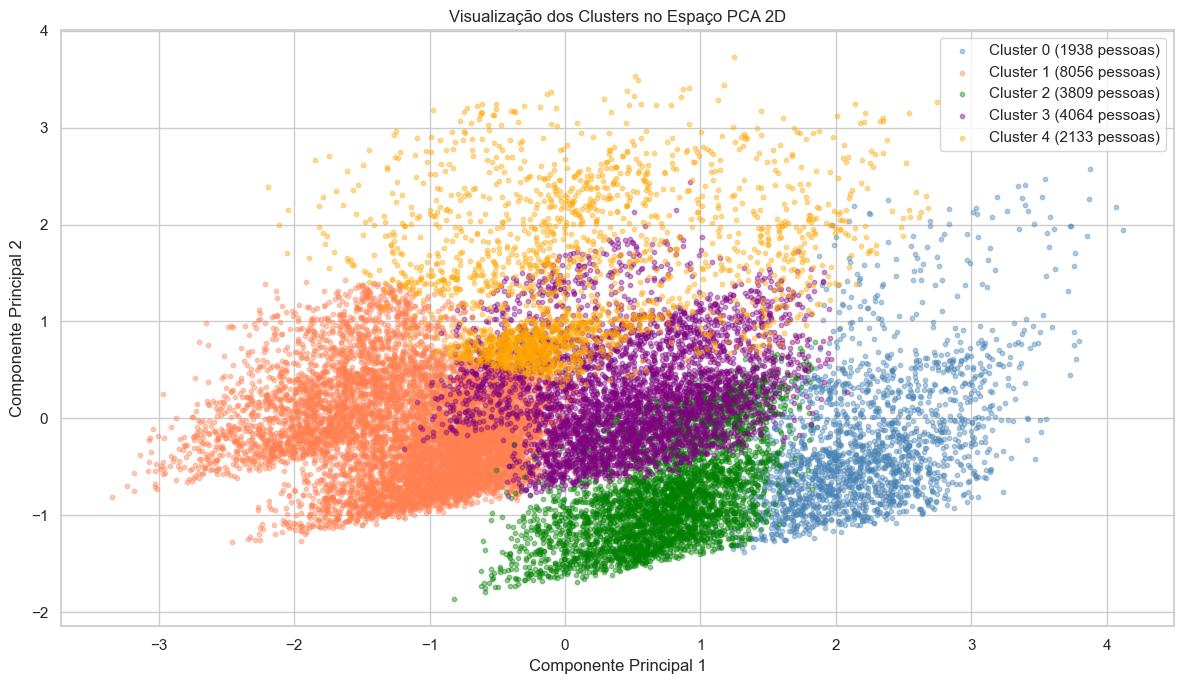

In [38]:
cores_cluster = {0: 'steelblue', 1: 'coral', 2: 'green', 3: 'purple', 4: 'orange'}
cores_pontos = [cores_cluster[l] for l in labels_final]

plt.figure(figsize=(12, 7))
for cluster in range(5):
    mask = labels_final == cluster
    plt.scatter(df_pca_2d[mask, 0], df_pca_2d[mask, 1],
                c=cores_cluster[cluster], alpha=0.4, s=10,
                label=f'Cluster {cluster} ({mask.sum()} pessoas)')

plt.title('Visualização dos Clusters no Espaço PCA 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.tight_layout()
plt.show()

### 3.6 Perfil Médio por Cluster

In [39]:
df_modelo['Cluster'] = labels_final
perfil_clusters = df_modelo.groupby('Cluster').mean().round(4)
display(perfil_clusters.T)

Cluster,0,1,2,3,4
Rent_pct,0.2980,0.1836,0.3000,0.1880,0.2016
Loan_Repayment_pct,0.1388,0.0091,0.0088,0.1378,0.0291
Disposable_pct,0.0784,0.3392,0.2198,0.1906,0.2839
Desired_Savings_pct,0.0988,0.0852,0.0907,0.0901,0.1741
Age,41.1213,41.0408,41.0231,41.0027,40.9841
Dependents,2.2064,1.8429,1.9097,2.1476,2.2480
Gap_Poupanca,0.0204,-0.2540,-0.1291,-0.1005,-0.1098
City_Tier_enc,2.9799,1.6722,3.0000,1.7601,1.9269
Gastos_Consumo_pct,0.1974,0.1936,0.1942,0.1971,0.1976
Gastos_Fixos_pct,0.1403,0.1390,0.1399,0.1408,0.1413


### 3.7 Radar Chart — Perfil Comportamental por Persona

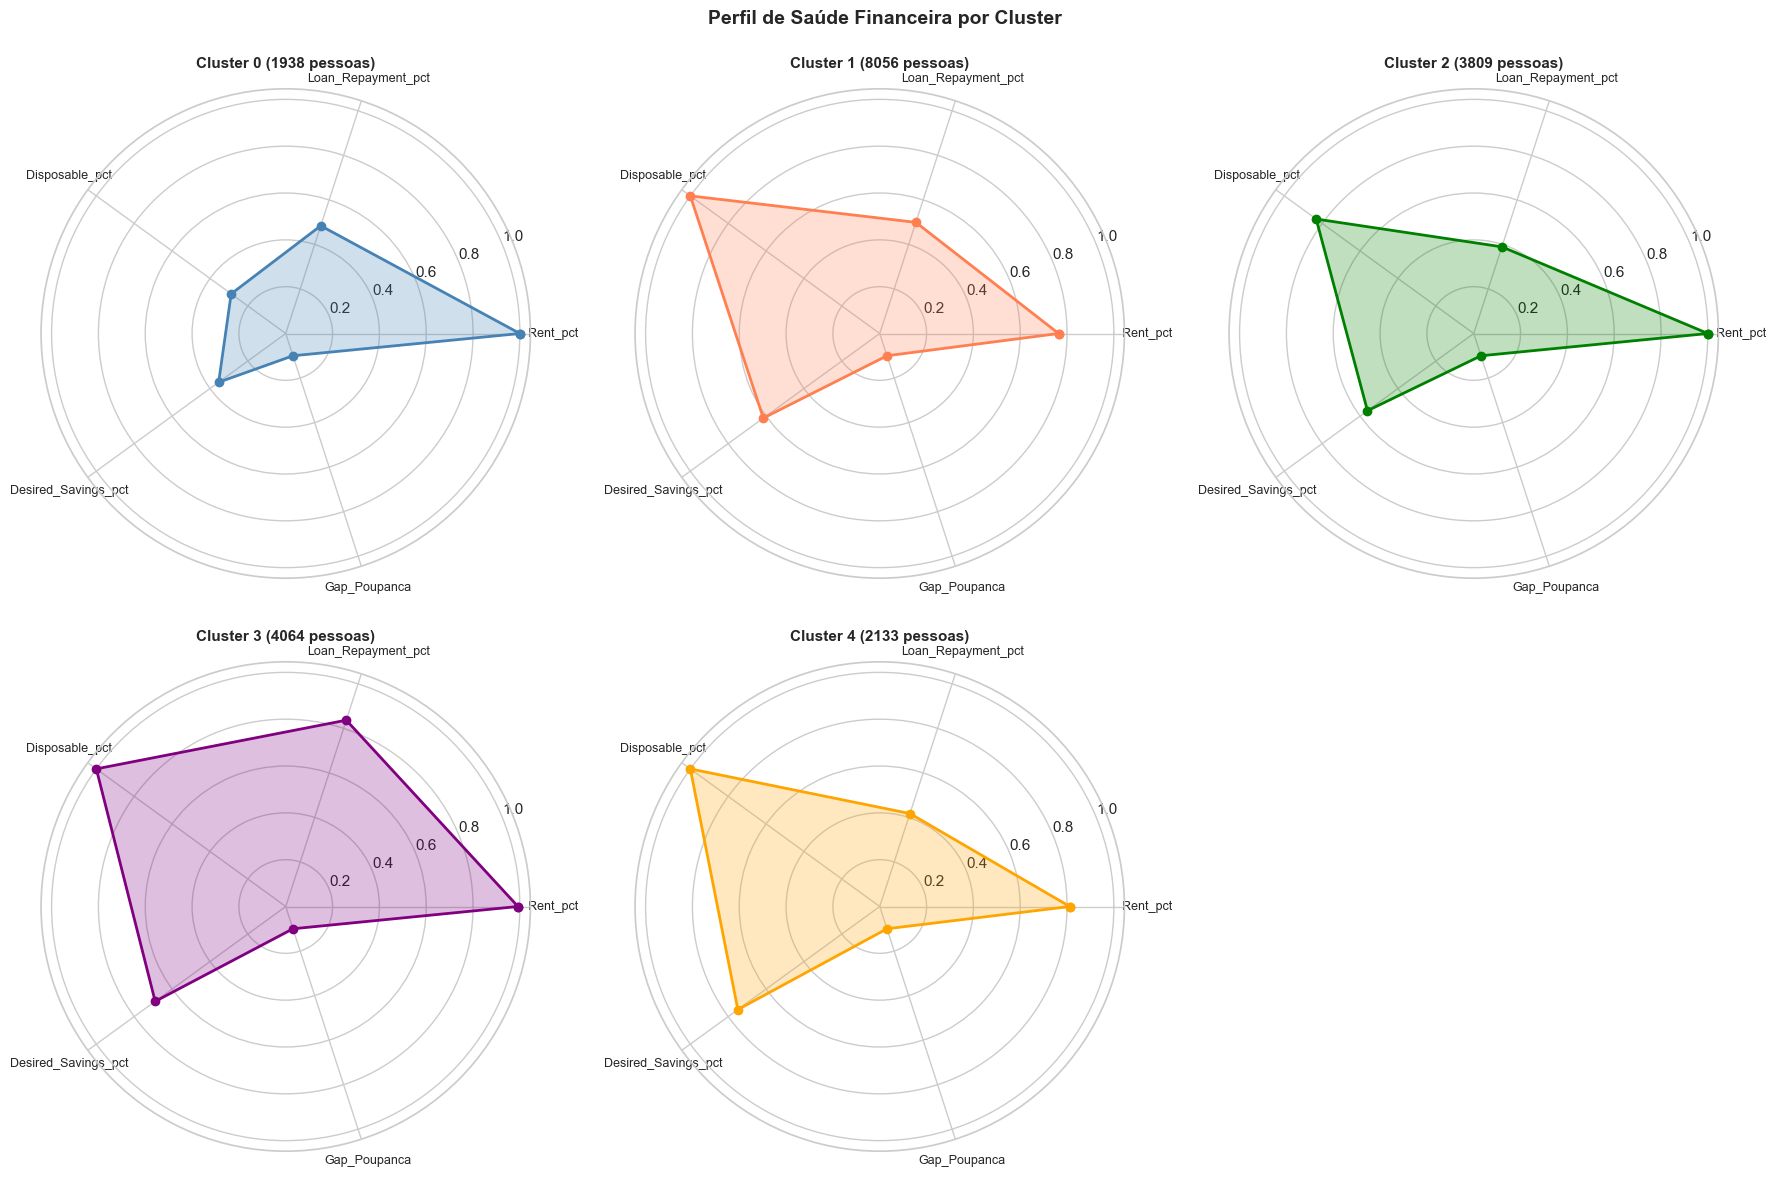

In [40]:
import matplotlib.pyplot as plt
import numpy as np

categorias_radar = ['Rent_pct', 'Loan_Repayment_pct', 'Disposable_pct',
                    'Desired_Savings_pct', 'Gap_Poupanca']

perfil_radar = perfil_clusters[categorias_radar].copy()
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler(feature_range=(0.1, 1.0))
perfil_norm = pd.DataFrame(
    scaler_radar.fit_transform(perfil_radar.T).T,
    index=perfil_radar.index,
    columns=perfil_radar.columns
)

N = len(categorias_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
cores = ['steelblue', 'coral', 'green', 'purple', 'orange']
contagem = pd.Series(labels_final).value_counts().sort_index()

for i in range(5):
    valores = perfil_norm.iloc[i].values.tolist()
    valores += valores[:1]
    axes[i].plot(angles, valores, 'o-', linewidth=2, color=cores[i])
    axes[i].fill(angles, valores, alpha=0.25, color=cores[i])
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(categorias_radar, size=9)
    axes[i].set_title(f'Cluster {i} ({contagem[i]} pessoas)',
                      size=11, fontweight='bold', pad=15)

axes[5].set_visible(False)
plt.suptitle('Perfil de Saúde Financeira por Cluster', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Princípio de Pareto — Comprometimento Financeiro por Persona

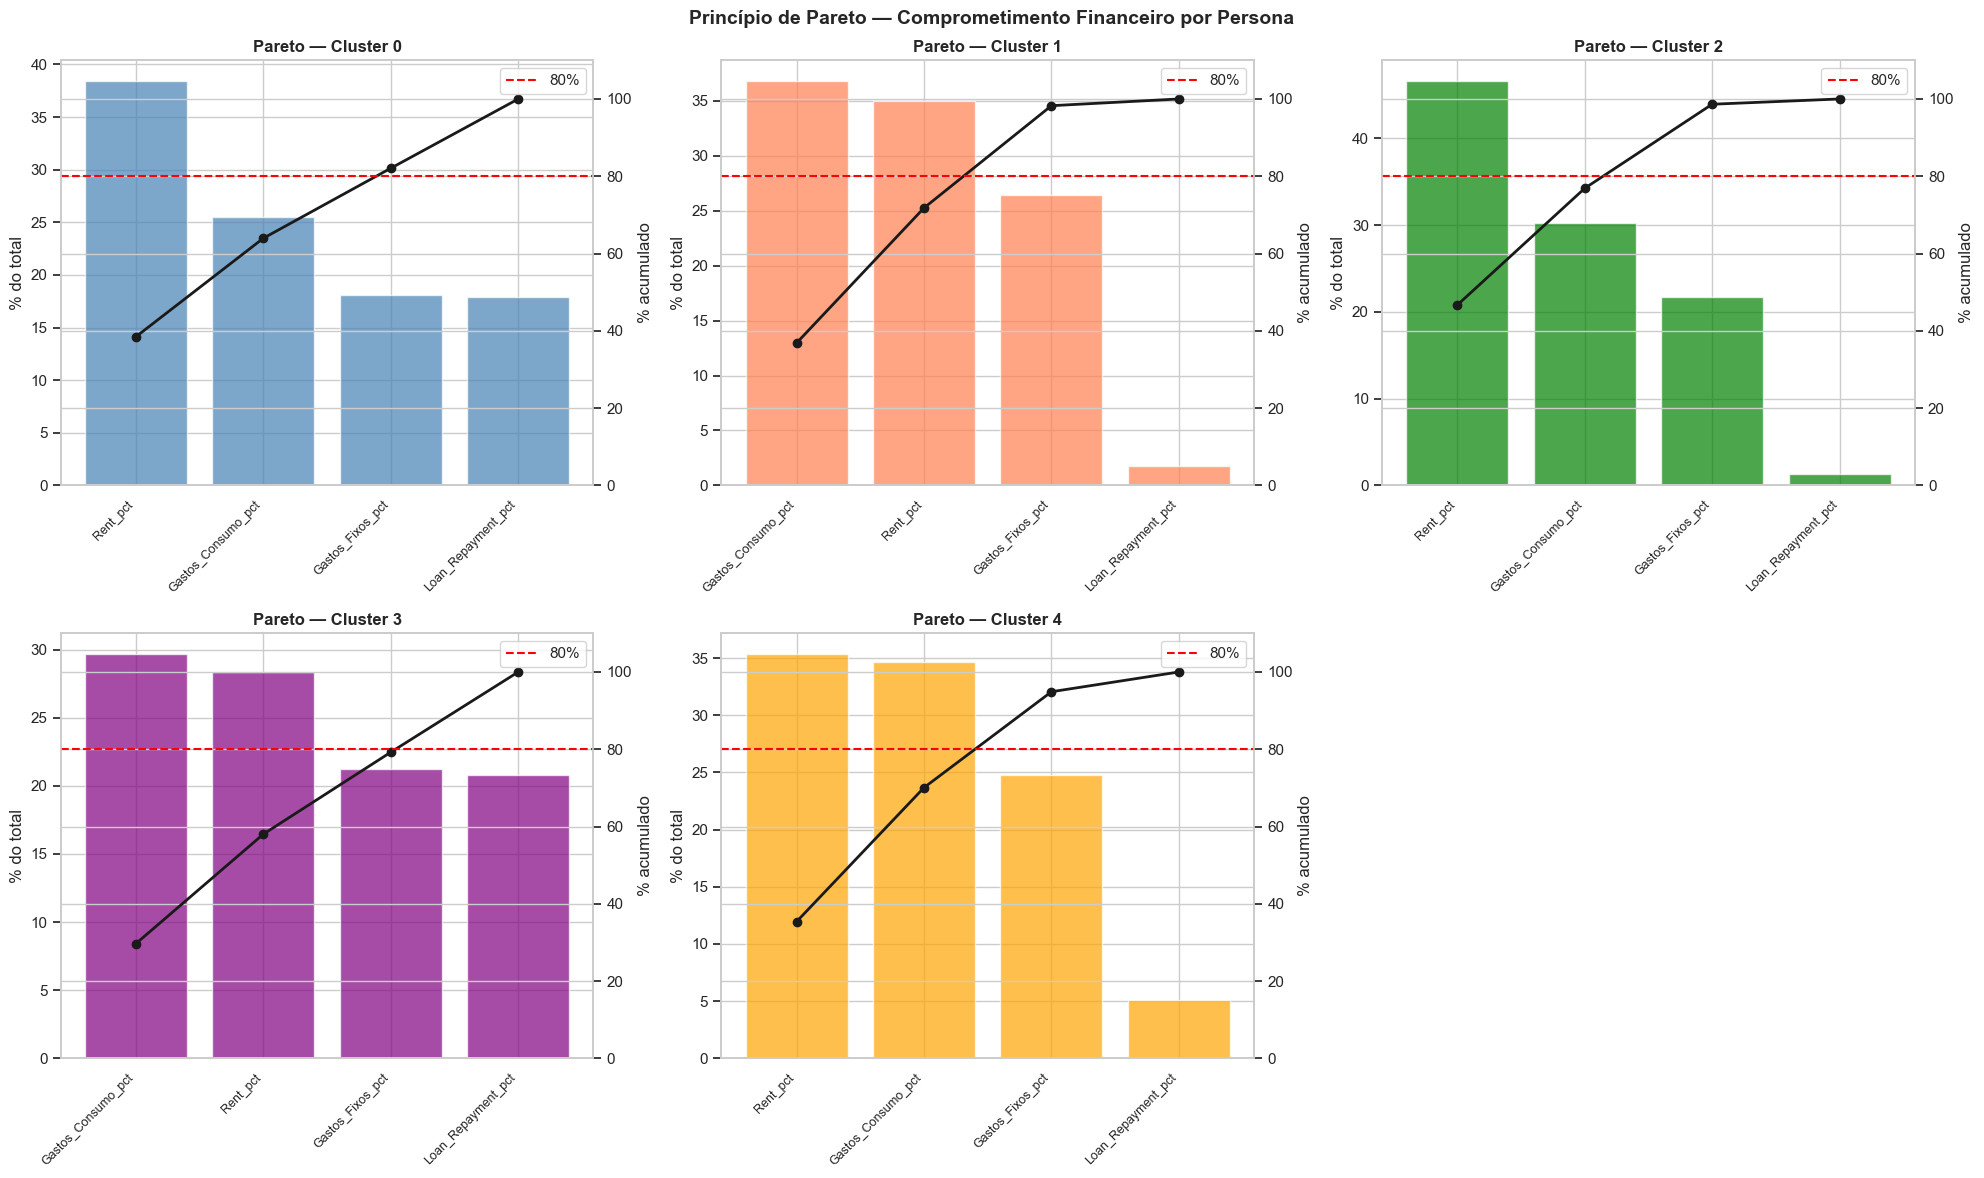

In [41]:
cores = ['steelblue', 'coral', 'green', 'purple', 'orange']

colunas_pareto = ['Rent_pct', 'Loan_Repayment_pct',
                  'Gastos_Consumo_pct', 'Gastos_Fixos_pct']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i in range(5):
    dados_cluster = df_modelo[df_modelo['Cluster'] == i][colunas_pareto].mean()
    dados_sorted = dados_cluster.abs().sort_values(ascending=False)
    percentual = dados_sorted / dados_sorted.sum() * 100
    cumulativo = percentual.cumsum()

    ax = axes[i]
    ax.bar(range(len(percentual)), percentual, color=cores[i], alpha=0.7)
    ax2 = ax.twinx()
    ax2.plot(range(len(cumulativo)), cumulativo, 'ko-', linewidth=2)
    ax2.axhline(y=80, color='red', linestyle='--', label='80%')
    ax.set_xticks(range(len(percentual)))
    ax.set_xticklabels(percentual.index, rotation=45, ha='right', size=9)
    ax.set_title(f'Pareto — Cluster {i}', fontweight='bold')
    ax.set_ylabel('% do total')
    ax2.set_ylabel('% acumulado')
    ax2.set_ylim(0, 110)
    ax2.legend()

axes[5].set_visible(False)

plt.suptitle('Princípio de Pareto — Comprometimento Financeiro por Persona',
             size=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.9 Resumo das Personas

In [42]:
resumo_personas = pd.DataFrame({
    'Cluster': [0, 1, 2, 3, 4],
    'Persona': ['Persona A', 'Persona B', 'Persona C', 'Persona D', 'Persona E'],
    'Pessoas': df['Cluster'].value_counts().sort_index().values,
    'Rent_pct':            df_modelo.groupby('Cluster')['Rent_pct'].mean().round(3).values,
    'Loan_Repayment_pct':  df_modelo.groupby('Cluster')['Loan_Repayment_pct'].mean().round(3).values,
    'Disposable_pct':      df_modelo.groupby('Cluster')['Disposable_pct'].mean().round(3).values,
    'Desired_Savings_pct': df_modelo.groupby('Cluster')['Desired_Savings_pct'].mean().round(3).values,
    'Gap_Poupanca':        df_modelo.groupby('Cluster')['Gap_Poupanca'].mean().round(3).values,
})

display(resumo_personas)

,Cluster,Persona,Pessoas,Rent_pct,Loan_Repayment_pct,Disposable_pct,Desired_Savings_pct,Gap_Poupanca
0,0,Persona A,1938,0.298,0.139,0.078,0.099,0.020
1,1,Persona B,8056,0.184,0.009,0.339,0.085,-0.254
2,2,Persona C,3809,0.300,0.009,0.220,0.091,-0.129
3,3,Persona D,4064,0.188,0.138,0.191,0.090,-0.100
4,4,Persona E,2133,0.202,0.029,0.284,0.174,-0.110


In [43]:
PERSONAS = {
    0: {'nome': 'Cluster 0', 'cor': '#4C9BE8'},
    1: {'nome': 'Cluster 1', 'cor': '#E8834C'},
    2: {'nome': 'Cluster 2', 'cor': '#4CAF50'},
    3: {'nome': 'Cluster 3', 'cor': '#9B59B6'},
    4: {'nome': 'Cluster 4', 'cor': '#E74C3C'},
}

print("Personas atualizadas:")
for k, v in PERSONAS.items():
    print(f"  Cluster {k} — {v['nome']}")

Personas atualizadas:
  Cluster 0 — Cluster 0
  Cluster 1 — Cluster 1
  Cluster 2 — Cluster 2
  Cluster 3 — Cluster 3
  Cluster 4 — Cluster 4


### 3.10 Interpretabilidade: SHAP Values

Modelo substituto Random Forest treinado com os labels do K-Means++ para calcular a importância das variáveis via SHAP. A acurácia do surrogate indica o quão bem ele reproduz as fronteiras do K-Means no espaço original.

In [44]:
from sklearn.ensemble import RandomForestClassifier
import shap

X_shap = df_modelo.drop(columns=[c for c in ['Cluster', 'Cluster_DBSCAN', 'Cluster_str']
                                  if c in df_modelo.columns])
feature_names = X_shap.columns.tolist()

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_shap, labels_final)
print(f"RF surrogate accuracy: {rf.score(X_shap, labels_final):.3f}")

RF surrogate accuracy: 0.997


In [45]:
sample_idx  = np.random.RandomState(42).choice(len(X_shap), 2000, replace=False)
X_sample    = X_shap.iloc[sample_idx]
lbl_sample  = labels_final[sample_idx]

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP calculado. Shape: {np.array(shap_values).shape}")

SHAP calculado. Shape: (2000, 10, 5)


#### 3.10.1 Beeswarm Global

Importância global das variáveis com direção de impacto: média sobre todas as classes. Variáveis no topo são as mais discriminantes entre as personas.

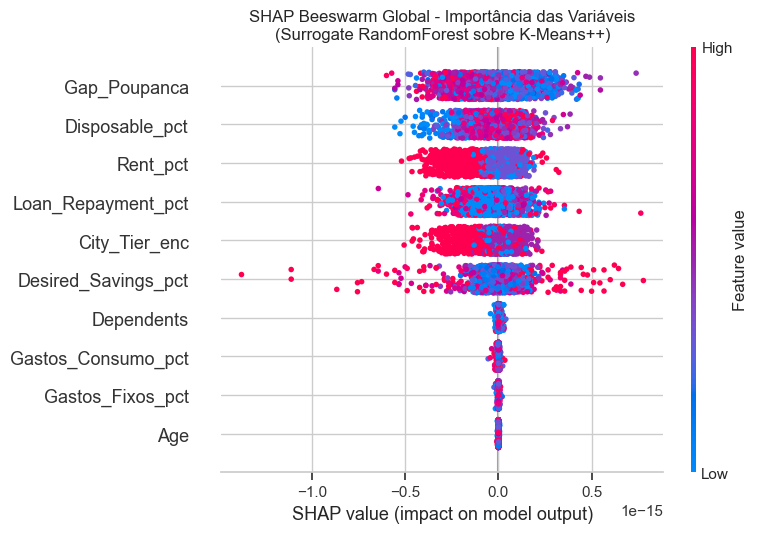

In [46]:
# Beeswarm global sem valor absoluto
# Mostra direção real do impacto de cada variável
shap_values_array = np.array(shap_values)

# Média sobre as classes para mostrar impacto geral
shap_mean = shap_values_array.mean(axis=2)

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_mean, X_sample, feature_names=feature_names,
                  plot_type='dot', show=False, color_bar=True)
plt.title('SHAP Beeswarm Global - Importância das Variáveis\n'
          '(Surrogate RandomForest sobre K-Means++)')
plt.tight_layout()
plt.show()

#### 3.10.2 Beeswarm por Cluster

Importância das variáveis para cada persona individualmente, permite entender o que define cada cluster especificamente.

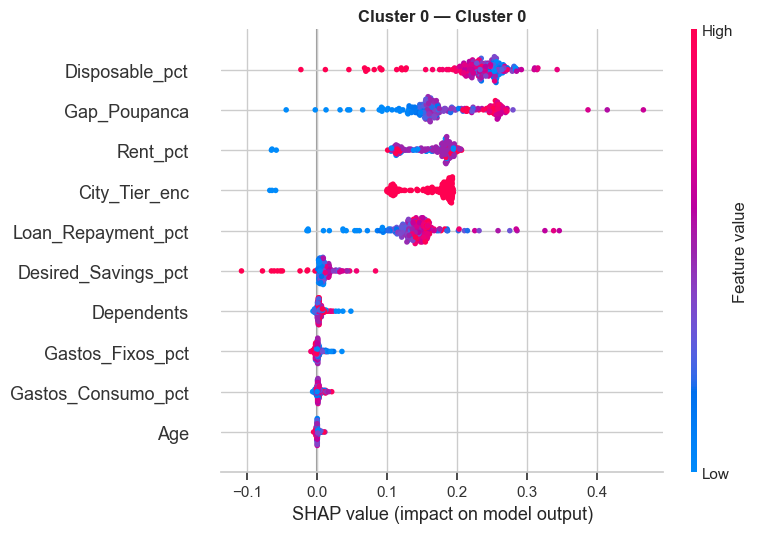

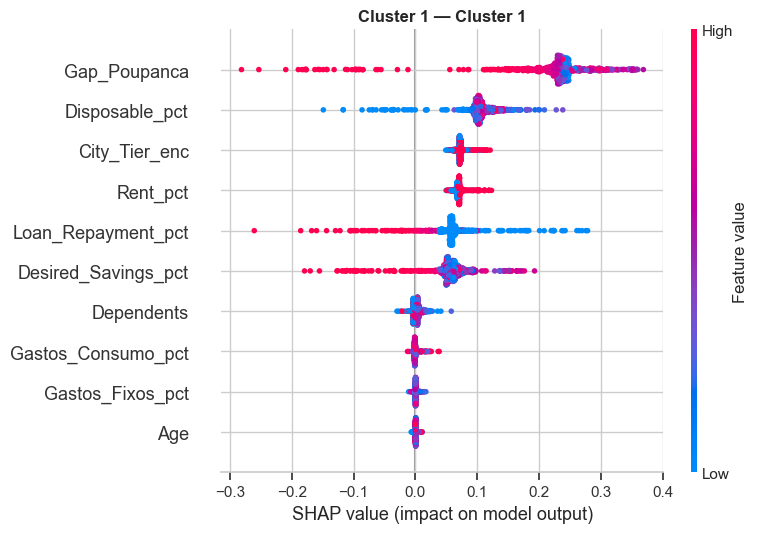

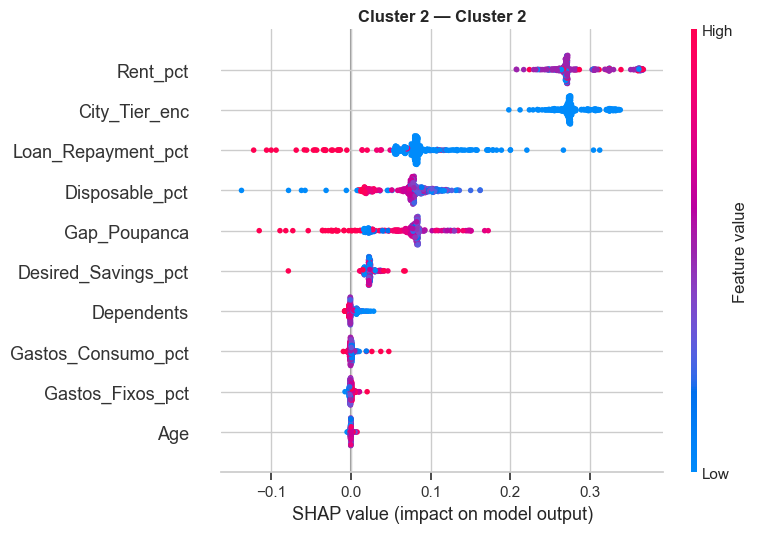

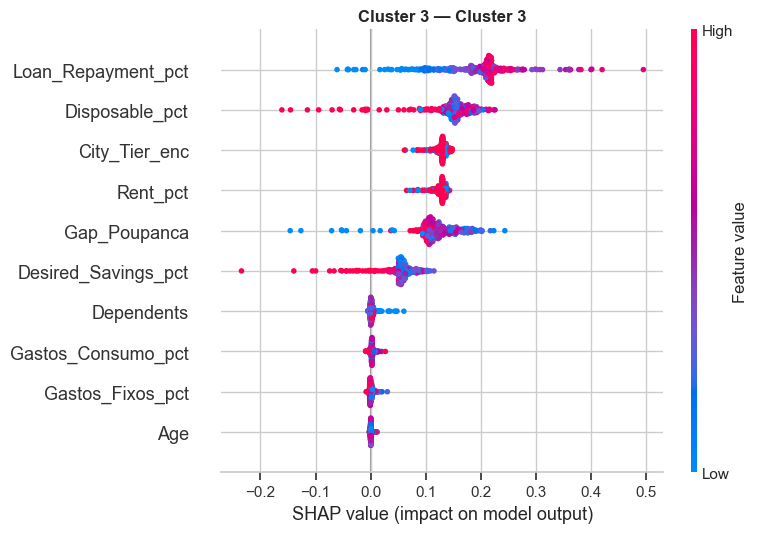

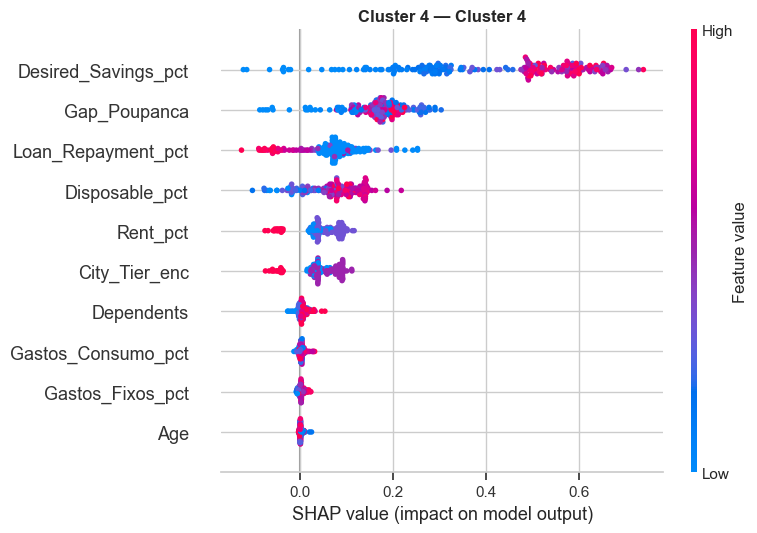

In [47]:
for c in range(5):
    mask   = lbl_sample == c
    shap_c = np.array(shap_values)[mask, :, c]

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_c, X_sample[mask], feature_names=feature_names,
                      plot_type='dot', show=False, color_bar=True)
    plt.title(f"Cluster {c} — {PERSONAS[c]['nome']}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 3.11 Exportação dos Artefatos

Salvamento do pipeline completo (scaler, PCA, modelo, personas e métricas) em arquivo `.pkl` para uso em produção ou inferência futura.

In [48]:
import joblib
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_final = silhouette_score(df_pca, labels_final, sample_size=3000, random_state=42)
db_final  = davies_bouldin_score(df_pca, labels_final)

artefatos = {
    'scaler':        scaler,
    'pca':           pca,
    'modelo':        modelo_final,
    'personas':      PERSONAS,
    'feature_names': list(df_modelo.drop(columns=['Cluster']).columns),
    'metricas':      {'silhouette': sil_final, 'davies_bouldin': db_final},
}

joblib.dump(artefatos, 'modelo_kmeans_personas.pkl')
print(f"Modelo salvo!")
print(f"Silhouette: {sil_final:.4f} | Davies-Bouldin: {db_final:.4f}")

Modelo salvo!
Silhouette: 0.2219 | Davies-Bouldin: 1.5041


In [49]:
resultados = []
for i in range(5):
    mask = labels_final == i
    dados = df_modelo[mask][['Disposable_pct', 'Gap_Poupanca', 'Rent_pct',
                              'Loan_Repayment_pct', 'City_Tier_enc',
                              'Desired_Savings_pct', 'Dependents']].mean().round(3)
    dados['Cluster'] = i
    dados['N_Pessoas'] = mask.sum()
    resultados.append(dados)

tabela = pd.DataFrame(resultados).set_index('Cluster')
display(tabela)

,Disposable_pct,Gap_Poupanca,Rent_pct,Loan_Repayment_pct,City_Tier_enc,Desired_Savings_pct,Dependents,N_Pessoas
Cluster,,,,,,,,
0.0,0.078,0.020,0.298,0.139,2.980,0.099,2.206,1938.0
1.0,0.339,-0.254,0.184,0.009,1.672,0.085,1.843,8056.0
2.0,0.220,-0.129,0.300,0.009,3.000,0.091,1.910,3809.0
3.0,0.191,-0.100,0.188,0.138,1.760,0.090,2.148,4064.0
4.0,0.284,-0.110,0.202,0.029,1.927,0.174,2.248,2133.0


In [50]:
with open('relatorio_personas_kmeans.txt', 'w', encoding='utf-8') as arquivo:

    arquivo.write("=" * 65 + "\n")
    arquivo.write(" RELATÓRIO DE PERSONAS (THINKMONEY) — K-MEANS++\n")
    arquivo.write("=" * 65 + "\n\n")

    descricoes = {
        0: """Perfil de alto comprometimento financeiro em centros urbanos de grande porte (Tier_1).
Apresenta a menor renda disponível do grupo (7,8%), com aluguel e parcelas de empréstimo
consumindo conjuntamente cerca de 44% da renda. É o único cluster com Gap de Poupança
positivo, indicando que a meta de poupança não é atingida na prática.""",

        1: """Perfil financeiramente saudável, predominante em cidades de médio e pequeno porte
(Tier_2/Tier_3). Apresenta a maior renda disponível (33,9%), ausência de empréstimos
relevantes e gap de poupança negativo expressivo (-25,4%), indicando que poupa
consistentemente acima da meta estabelecida.""",

        2: """Perfil urbano sem endividamento, localizado exclusivamente em cidades Tier_1.
O aluguel representa 30% da renda, sendo o principal fator de pressão financeira.
Apesar disso, mantém folga moderada (22%) e consegue poupar acima da meta.""",

        3: """Perfil com endividamento elevado em cidades de médio e pequeno porte.
O comprometimento com empréstimos (13,8% da renda) é o principal fator de pressão,
reduzindo a renda disponível para 19,1% apesar do aluguel relativamente baixo.""",

        4: """Perfil com maior ambição de poupança do grupo (meta de 17,4% da renda) e
capacidade de cumpri-la, apresentando gap negativo de -11%. Boa renda disponível (28,4%)
e baixo endividamento caracterizam este perfil como o de maior disciplina financeira."""
    }

    for i in range(5):
        mask = labels_final == i
        n = mask.sum()
        pct = n / len(labels_final) * 100

        arquivo.write(f"CLUSTER {i} — {n} pessoas ({pct:.1f}% da base)\n")
        arquivo.write("-" * 65 + "\n")
        arquivo.write(descricoes[i].strip() + "\n\n")

        dados = df_modelo[mask][['Disposable_pct', 'Gap_Poupanca', 'Rent_pct',
                                  'Loan_Repayment_pct', 'City_Tier_enc',
                                  'Desired_Savings_pct', 'Dependents']].mean().round(3)

        arquivo.write("Métricas médias:\n")
        for col, val in dados.items():
            arquivo.write(f"  {col}: {val}\n")

        arquivo.write("=" * 65 + "\n\n")

print("Relatório salvo em relatorio_personas_kmeans.txt")

Relatório salvo em relatorio_personas_kmeans.txt



## Bloco 4 — Comparação entre DBSCAN e K-Means++
### 4.1 Métricas de Validação

In [51]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# K-Means++ — usando labels_final já calculado
sil_kmeans = silhouette_score(df_pca, labels_final, sample_size=3000, random_state=42)
db_kmeans = davies_bouldin_score(df_pca, labels_final)

# DBSCAN — recalcula excluindo ruído
dbscan_final = DBSCAN(eps=0.70, min_samples=12)
labels_dbscan = dbscan_final.fit_predict(df_pca)
mascara = labels_dbscan != -1
sil_dbscan = silhouette_score(df_pca[mascara], labels_dbscan[mascara],
                               sample_size=3000, random_state=42)
db_dbscan = davies_bouldin_score(df_pca[mascara], labels_dbscan[mascara])

# Ruído do DBSCAN
n_ruido = (labels_dbscan == -1).sum()
pct_ruido = n_ruido / len(labels_dbscan) * 100

comparacao = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Davies-Bouldin', 'Nº Clusters',
                'Ruído Isolado', 'K predefinido', 'Geometria assumida'],
    'K-Means++': [f'{sil_kmeans:.4f}', f'{db_kmeans:.4f}', '5',
                  'Não aplicável', 'Sim (K=5)', 'Esférica'],
    'DBSCAN':    [f'{sil_dbscan:.4f}', f'{db_dbscan:.4f}', '5',
                  f'{n_ruido} ({pct_ruido:.1f}%)', 'Não', 'Livre']
})

display(comparacao)

,Métrica,K-Means++,DBSCAN
0,Silhouette Score,0.2219,0.1258
1,Davies-Bouldin,1.5041,1.6867
2,Nº Clusters,5,5
3,Ruído Isolado,Não aplicável,1208 (6.0%)
4,K predefinido,Sim (K=5),Não
5,Geometria assumida,Esférica,Livre


### 4.2 Convergência dos Resultados

Ambos os algoritmos convergiram naturalmente para 5 clusters, o que fortalece a validade da segmentação. Abaixo comparamos os perfis médios de cada cluster entre os dois modelos para verificar se as personas identificadas são consistentes.

In [52]:
# Perfil médio K-Means++
perfil_kmeans = df_modelo.drop(columns=[c for c in ['Cluster', 'Cluster_DBSCAN', 'Cluster_str']
                                         if c in df_modelo.columns]).copy()
perfil_kmeans['Cluster'] = labels_final
perfil_kmeans = perfil_kmeans.groupby('Cluster')[['Disposable_pct', 'Gap_Poupanca',
                                                    'Rent_pct', 'Loan_Repayment_pct']].mean().round(3)
perfil_kmeans.index = [f'KMeans Cluster {i}' for i in perfil_kmeans.index]

# Perfil médio DBSCAN (sem ruído)
perfil_dbscan = df_modelo.copy()
perfil_dbscan['Cluster'] = labels_dbscan
perfil_dbscan = perfil_dbscan[perfil_dbscan['Cluster'] != -1]
perfil_dbscan = perfil_dbscan.groupby('Cluster')[['Disposable_pct', 'Gap_Poupanca',
                                                    'Rent_pct', 'Loan_Repayment_pct']].mean().round(3)
perfil_dbscan.index = [f'DBSCAN Cluster {i}' for i in perfil_dbscan.index]

display(pd.concat([perfil_kmeans, perfil_dbscan]))

,Disposable_pct,Gap_Poupanca,Rent_pct,Loan_Repayment_pct
KMeans Cluster 0,0.078,0.020,0.298,0.139
KMeans Cluster 1,0.339,-0.254,0.184,0.009
KMeans Cluster 2,0.220,-0.129,0.300,0.009
KMeans Cluster 3,0.191,-0.100,0.188,0.138
KMeans Cluster 4,0.284,-0.110,0.202,0.029
DBSCAN Cluster 0,0.177,-0.085,0.300,0.047
DBSCAN Cluster 1,0.276,-0.182,0.200,0.049
DBSCAN Cluster 2,0.331,-0.240,0.150,0.044
DBSCAN Cluster 3,0.342,-0.110,0.150,0.000
DBSCAN Cluster 4,0.268,-0.036,0.300,0.000


### 4.3 Comparação Visual dos Perfis

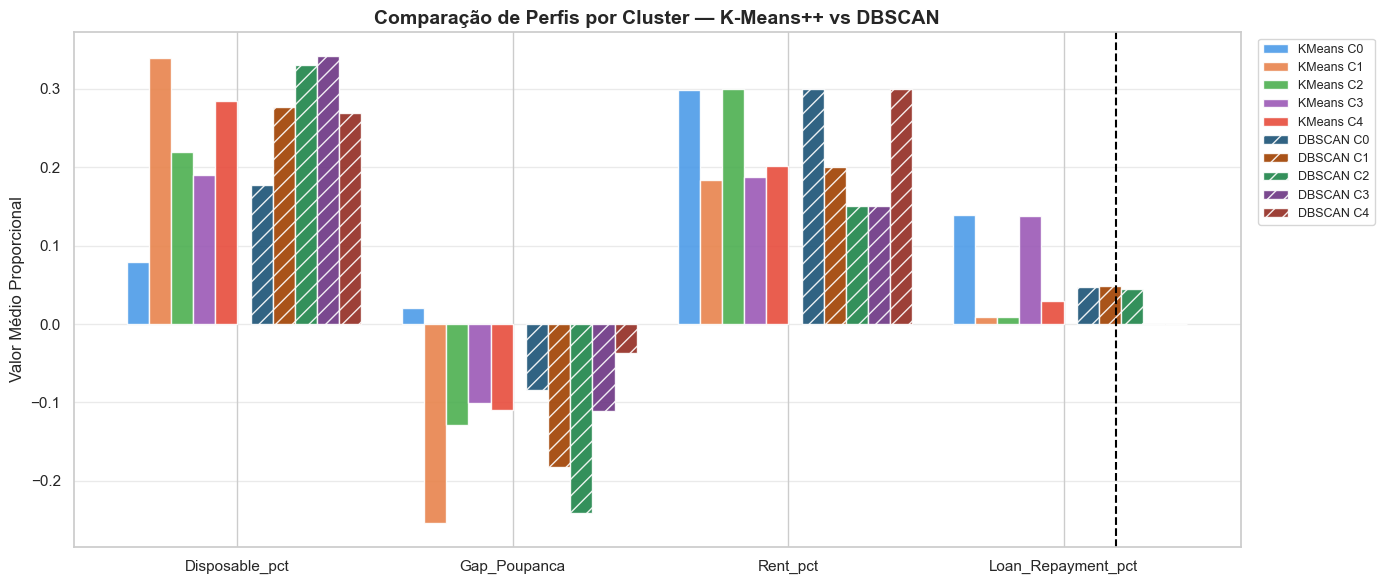

In [53]:
import matplotlib.pyplot as plt
import numpy as np

variaveis = ['Disposable_pct', 'Gap_Poupanca', 'Rent_pct', 'Loan_Repayment_pct']
x = np.arange(len(variaveis))
width = 0.08

fig, ax = plt.subplots(figsize=(14, 6))

cores_kmeans = ['#4C9BE8', '#E8834C', '#4CAF50', '#9B59B6', '#E74C3C']
cores_dbscan = ['#1a5276', '#a04000', '#1e8449', '#6c3483', '#922b21']

for i in range(5):
    mask_k = labels_final == i
    vals_k = df_modelo[mask_k][variaveis].mean().values
    ax.bar(x + i * width, vals_k, width,
           label=f'KMeans C{i}', color=cores_kmeans[i], alpha=0.9)

for i in range(5):
    mask_d = labels_dbscan == i
    vals_d = df_modelo[mask_d][variaveis].mean().values
    ax.bar(x + (i + 5) * width + 0.05, vals_d, width,
           label=f'DBSCAN C{i}', color=cores_dbscan[i], alpha=0.9, hatch='//')

ax.set_xticks(x + 4.5 * width)
ax.set_xticklabels(variaveis, fontsize=11)
ax.axvline(x=len(variaveis) - 0.45, color='black', linestyle='--', linewidth=1.5)
ax.set_ylabel('Valor Médio Proporcional')
ax.set_title('Comparação de Perfis por Cluster — K-Means++ vs DBSCAN',
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()